
# PL Batch Loader & Plotter (Peak Position vs Time, FWHM vs Time, Radius vs Time, and Radius Growth Rate vs Time)
*v3.1 Developed by Adam Printz and Patrick Lohr using ChatGPT5*

This notebook loads **multiple CSVs** of PL fit results from a directory, then:
- **Peak Position (eV)** vs **Time (s)** on the **left** y-axis, and **FWHM** vs **Time (s)** on the **right** y-axis
- **Peak Position (eV)** vs **Time (s)** on the **left** y-axis, and **Radius** vs **Time (s)** on the **right** y-axis
- Creates an interactive plot of the above so that 3 clicks can be made to define the beginning of growth region 1, end of growth region 1/beginning of growth region 2, and end of growth region 2/beginning of growth region 3
- Generates plots of **Peak Position (eV)** vs **Time (s)** on the **left** y-axis, and **Radius** vs **Time (s)** on the **right** y-axis with exponential fits to the **Radius** vs **Time (s)** plots
- Generates plots of **dRadius/dt (nm/s)** vs **Time (s)** with all samples and individually
- Produces a master xlsx book with all data, including imported data used for analysis
- Produces individual docx reports for each sample that includes all plots and information for fitting


### What you need to do
1. If your CSV column layout differs from the default, adjust `col_select` (`time`, `peak`, `fwhm` can be either indices or names).
2. Run all cells top to bottom.


# Setup: Run FIRST time only

In [1]:
# 🧰 Setup — install notebook dependencies (run once)
# Notes:
# - tk (for the file/folder picker) is a system package, not pip. See below.

# Upgrade build tools
%pip install --upgrade pip setuptools wheel

# Core scientific + plotting + interactivity + Excel + Word
%pip install numpy pandas matplotlib scipy plotly ipywidgets openpyxl xlsxwriter python-docx xlrd jupyterlab

# Enable ipywidgets in classic Notebook (JupyterLab 3+ usually needs nothing)
import sys, subprocess, pkgutil
try:
    import ipywidgets  # noqa
    if pkgutil.find_loader("widgetsnbextension"):
        subprocess.check_call(
            [sys.executable, "-m", "jupyter", "nbextension", "enable",
             "--py", "widgetsnbextension", "--sys-prefix"]
        )
except Exception as e:
    print("Widgets enable step skipped or not needed:", e)

# Quick smoke test
try:
    import numpy, pandas, matplotlib, scipy, plotly, ipywidgets, openpyxl, docx, xlrd  # noqa
    print("✅ All imports OK")
except Exception as err:
    print("⚠️ Import check failed:", err)

  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 10.4 MB/s eta 0:00:00
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)

   ---------------------------------------- 0/3 [wheel]
   ---------------------------------------- 0/3 [wheel]
   ---------------------------------------- 0/3 [wheel]
   ---------------------------------------- 0/3 [wheel]
   ---------------------------------------- 0/3 [wheel]
   ---------------------------------------- 0/3 [wheel]
  Attempting uninstall: setuptools
   ---------------------------------------- 0/3 [wheel]
    Found existing installation: setuptools 80.1.0
   ---------------------------------------- 0/3 [wheel]
   ------------- -------------------------- 1/3 [setuptools]
    Uninstalling setuptools-80.1.0:
   ------------- ----

C:\Users\raglo\AppData\Local\Temp\ipykernel_30192\3803092643.py:15: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("widgetsnbextension"):


Widgets enable step skipped or not needed: Command '['c:\\Users\\raglo\\anaconda3\\envs\\giwaxs_analysis_new3\\python.exe', '-m', 'jupyter', 'nbextension', 'enable', '--py', 'widgetsnbextension', '--sys-prefix']' returned non-zero exit status 1.
✅ All imports OK


# Imports & Global Plot Defaults
Sets up all core imports and consistent plotting defaults.
- Imports numpy/pandas/matplotlib and configures crisp figures and math fonts.
- Keeps styles uniform across every plot in the notebook.

In [2]:
%matplotlib inline

from __future__ import annotations
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple, Union

import os
import re
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Crisp, consistent figures + fonts (used by all cells)
plt.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['mathtext.fontset'] = 'dejavusans'
mpl.rcParams['mathtext.default'] = 'regular'


# Session, Paths, Selection & Shared Helpers
Single source of truth for file locations, selection, and utilities.
- Defines a `Session` (e.g., `<YYMMDD>_Data` root, `prefix`).
- Persists/loads **data folder** and **selected files** (across runs).
- Provides helpers to: filter items by saved selection, write Excel files, and rebuild `FIT_MODELS` from saved fit Excel files.


In [3]:
# ==== Session, paths, selection, small IO helpers ====

_DATA_DIR_SAVEFILE = Path.cwd() / ".selected_data_dir.txt"
_SELECTED_FILES_SAVEFILE = Path.cwd() / ".selected_files.txt"


def load_saved_data_dir() -> Path:
    if not _DATA_DIR_SAVEFILE.exists():
        raise FileNotFoundError("No saved Data folder. Run the picker cell.")
    p = Path(_DATA_DIR_SAVEFILE.read_text().strip())
    if not p.exists() or not p.is_dir():
        raise FileNotFoundError(f"Saved data_dir invalid: {p}")
    return p


@dataclass
class Session:
    data_dir: Path
    date_tag: str = field(
        default_factory=lambda: datetime.now().strftime("%y%m%d")
    )  # YYMMDD

    @property
    def day_root(self) -> Path:
        p = self.data_dir / f"{self.date_tag}_Data"
        p.mkdir(parents=True, exist_ok=True)
        return p

    def subdir(self, name: str) -> Path:
        p = self.day_root / name
        p.mkdir(parents=True, exist_ok=True)
        return p

    @property
    def prefix(self) -> str:
        return f"{self.date_tag}_"


# --- selection state ---
def save_selected_files(files: List[Path] | None) -> None:
    files = [Path(p).resolve() for p in (files or []) if p]
    if not files:
        _SELECTED_FILES_SAVEFILE.unlink(missing_ok=True)
        return
    _SELECTED_FILES_SAVEFILE.write_text("\n".join(map(str, files)))


def load_selected_files() -> List[Path]:
    if not _SELECTED_FILES_SAVEFILE.exists():
        return []
    paths = [
        Path(ln.strip())
        for ln in _SELECTED_FILES_SAVEFILE.read_text().splitlines()
        if ln.strip()
    ]
    return [p.resolve() for p in paths if p.exists() and p.is_file()]


def find_sample_source_path(sample_obj) -> Optional[Path]:
    for attr in (
        "source_path",
        "filepath",
        "file_path",
        "path",
        "file",
        "filename",
        "source",
    ):
        if hasattr(sample_obj, attr):
            try:
                p = Path(getattr(sample_obj, attr))
                return p if p else None
            except Exception:
                pass
    return None


def filter_items_by_saved(
    items: List[Tuple[str, object]], saved: List[Path]
) -> List[Tuple[str, object]]:
    if not saved:
        return items
    stems = {p.stem.lower() for p in saved}
    keep = []
    for name, obj in items:
        if isinstance(name, str) and name.lower() in stems:
            keep.append((name, obj))
            continue
        src = find_sample_source_path(obj)
        if src and src.stem.lower() in stems:
            keep.append((name, obj))
    return keep


# --- XLSX helper ---
def write_xlsx(path: Path, sheets: Dict[str, pd.DataFrame]) -> None:
    path = Path(path)
    with pd.ExcelWriter(path, engine="openpyxl") as w:
        for sheet, df in sheets.items():
            df.to_excel(w, sheet_name=sheet, index=False)


# --- FIT_MODELS loader (used by Growth + Word report) ---
def load_fit_models(session: Session) -> dict:
    root = session.subdir("Peak Energy and Radius vs Time (fitting)")
    models = {}
    for xlsx in root.glob("*.xlsx"):
        m = re.match(r"(\d{6})_(.+)_fit_data\.xlsx$", xlsx.name)
        if not m:
            continue
        name = m.group(2)
        try:
            df_fit = pd.read_excel(xlsx, sheet_name="Fit_Parameters")
            df_raw = pd.read_excel(xlsx, sheet_name="Raw_Data")
        except Exception:
            continue
        try:
            t_abs = np.asarray(df_raw["Time_abs (s)"], float)
            t_rel = np.asarray(df_raw["Time_rel (s)"], float)
            t0 = float(t_abs[0] - t_rel[0])
        except Exception:
            t0 = 0.0

        regs = []
        for _, row in df_fit.iterrows():
            A = float(row["A"]) if pd.notna(row["A"]) else np.nan
            tau = float(row["Tau"]) if pd.notna(row["Tau"]) else np.nan
            C = float(row["C"]) if pd.notna(row["C"]) else np.nan
            R2 = float(row["R_squared"]) if pd.notna(row["R_squared"]) else np.nan
            t0a = (
                float(row["Dashed_Start_s_abs"])
                if pd.notna(row["Dashed_Start_s_abs"])
                else np.nan
            )
            t1a = (
                float(row["Dashed_End_s_abs"])
                if pd.notna(row["Dashed_End_s_abs"])
                else np.nan
            )
            t0n = (t0a - t0) if np.isfinite(t0a) else np.nan
            t1n = (t1a - t0) if np.isfinite(t1a) else np.nan

            if np.isfinite(A) and np.isfinite(tau):
                f_norm = (
                    lambda A=A, tau=tau, C=C: (lambda t: A * np.exp(-t / tau) + C)
                )()
                df_norm = (
                    lambda A=A, tau=tau: (lambda t: -(A / tau) * np.exp(-t / tau))
                )()
                f_abs = (
                    lambda A=A, tau=tau, C=C, t0=t0: (
                        lambda ta: A * np.exp(-(ta - t0) / tau) + C
                    )
                )()
                df_abs = (
                    lambda A=A, tau=tau, t0=t0: (
                        lambda ta: -(A / tau) * np.exp(-(ta - t0) / tau)
                    )
                )()
            else:
                f_norm = df_norm = f_abs = df_abs = None

            regs.append(
                {
                    "A": A,
                    "tau": tau,
                    "C": C,
                    "R2": R2,
                    "t_start_norm": t0n,
                    "t_end_norm": t1n,
                    "t_start_abs": t0a,
                    "t_end_abs": t1a,
                    "f_norm": f_norm,
                    "df_norm": df_norm,
                    "f_abs": f_abs,
                    "df_abs": df_abs,
                }
            )
        models[name] = {"t0_offset": t0, "regions": regs}
    return models

# Pick Data (Folder or Files) & Initialize Session
Interactive picker with console fallback, then session bootstrap.
- Lets you select either **files** (uses their common parent) or a **folder**.
- Persists choices to `.selected_data_dir.txt` & `.selected_files.txt`.
- Creates a `Session` for the day and sets basic run-time options (e.g., `target_time`, `col_select`).


In [4]:
# ==== Folder / files picker (GUI with console fallback) ====


def _common_parent(paths: List[Union[str, Path]]) -> Path:
    if len(paths) == 1:
        return Path(paths[0]).resolve().parent
    parents = [str(Path(p).resolve().parent) for p in paths]
    common = os.path.commonpath(parents)
    return Path(common)


def pick_data_location_gui(
    prompt_title_files="Select one or more data files",
    prompt_title_dir="Select data folder",
    filetypes=(("CSV files", "*.csv"), ("Text files", "*.txt"), ("All files", "*.*")),
) -> tuple[Path, List[Path]]:
    try:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.update()

        files = filedialog.askopenfilenames(
            title=prompt_title_files, filetypes=filetypes
        )
        if files:
            files = [str(f) for f in files]
            data_dir = _common_parent(files)
            root.destroy()
            _DATA_DIR_SAVEFILE.write_text(str(data_dir))
            print(f"✅ Using data_dir (from files' parent): {data_dir}")
            return data_dir, [Path(f) for f in files]

        selected_dir = filedialog.askdirectory(title=prompt_title_dir)
        root.destroy()
        if selected_dir:
            data_dir = Path(selected_dir)
            _DATA_DIR_SAVEFILE.write_text(str(data_dir))
            print(f"✅ Using data_dir (selected folder): {data_dir}")
            return data_dir, []

        raise RuntimeError("No selection made.")

    except Exception:
        print("⚠️ GUI picker unavailable or canceled.")
        print("Paste a folder path OR a comma-separated list of files.")
        try:
            raw = input("Path(s): ").strip()
        except EOFError:
            raw = ""
        if not raw:
            raise RuntimeError("No input provided.")

        parts = [Path(p.strip()).expanduser() for p in raw.split(",") if p.strip()]
        dirs = [p for p in parts if p.exists() and p.is_dir()]
        files = [p for p in parts if p.exists() and p.is_file()]

        if dirs:
            data_dir = dirs[0].resolve()
            _DATA_DIR_SAVEFILE.write_text(str(data_dir))
            print(f"✅ Using data_dir (from pasted folder): {data_dir}")
            return data_dir, []
        if files:
            data_dir = _common_parent(files)
            _DATA_DIR_SAVEFILE.write_text(str(data_dir))
            print(f"✅ Using data_dir (from files' parent): {data_dir}")
            return data_dir, [p.resolve() for p in files]
        raise FileNotFoundError("None of the provided paths exist.")


# --- Run the picker (or reuse saved) ---
try:
    data_dir, selected_files = pick_data_location_gui()
except Exception:
    # Fallback to saved directory if picker not used this run
    data_dir = load_saved_data_dir()
    selected_files = []

# Persist selected files for later filtering
save_selected_files(selected_files)

# Session object for this whole run/day
session = Session(data_dir=data_dir)

# Run-time settings
target_time = 375  # seconds; None = auto-scale
col_select = {"time": 0, "peak": 3, "fwhm": 4}  # indices or names

print(f"📁 Selected files: {len(selected_files)}")
print(f"✅ Using data_dir: {session.data_dir}")
print(f"📦 Export root:   {session.day_root}")

✅ Using data_dir (from files' parent): E:\printz_Apr2024\MAPI_YL\working_files\MAPI_1pct_AVA_S1_18_30min\output
📁 Selected files: 1
✅ Using data_dir: E:\printz_Apr2024\MAPI_YL\working_files\MAPI_1pct_AVA_S1_18_30min\output
📦 Export root:   E:\printz_Apr2024\MAPI_YL\working_files\MAPI_1pct_AVA_S1_18_30min\output\260114_Data


# Batch Loader (SamplePL/PLBatch) & Load Data
Data model for one sample and a collection, then load all samples.
- Supports CSV/TXT/TSV/Excel ingestion and column resolution by index or name.
- Cleans per-sample DataFrames (drop NaNs, optional time cutoff).
- Loads selected files (or all matching in folder) and prints a short preview.


In [5]:
# ==== Batch loader (SamplePL / PLBatch) ====
from dataclasses import dataclass, field

ColSel = Dict[
    str, Union[int, str]
]  # {"time": idx_or_name, "peak": idx_or_name, "fwhm": idx_or_name}


def _resolve_col(df: pd.DataFrame, sel: Union[int, str]) -> str:
    return df.columns[sel] if isinstance(sel, int) else sel


def _read_table(path: Path) -> pd.DataFrame:
    suf = path.suffix.lower()
    if suf in {".csv", ".txt", ".tsv"}:
        return pd.read_csv(path, sep=None, engine="python")
    if suf in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type: {path.suffix} ({path})")


@dataclass
class SamplePL:
    name: str
    path: Path
    target_time: Optional[float] = None
    col_select: Optional[ColSel] = None

    df_raw: pd.DataFrame = field(init=False, repr=False)
    df_clean: pd.DataFrame = field(init=False, repr=False)
    columns_resolved: Dict[str, str] = field(init=False, default_factory=dict)

    def __post_init__(self) -> None:
        self.df_raw = _read_table(self.path)
        if self.col_select is None:
            self.col_select = {"time": 0, "peak": 3, "fwhm": 4}
        for key in ("time", "peak", "fwhm"):
            self.columns_resolved[key] = _resolve_col(self.df_raw, self.col_select[key])

        peak_col = self.columns_resolved["peak"]
        self.df_clean = self.df_raw.dropna(subset=[peak_col]).copy()
        if self.target_time is not None:
            time_col = self.columns_resolved["time"]
            self.df_clean = self.df_clean[self.df_clean[time_col] <= self.target_time]

    @property
    def time_column(self) -> str:
        return self.columns_resolved["time"]

    @property
    def peak_column(self) -> str:
        return self.columns_resolved["peak"]

    @property
    def fwhm_column(self) -> str:
        return self.columns_resolved["fwhm"]

    @property
    def source_path(self) -> Path:
        return self.path

    def head(self, n: int = 5) -> pd.DataFrame:
        return self.df_clean.head(n)


class PLBatch:
    def __init__(
        self, target_time: Optional[float] = None, col_select: Optional[ColSel] = None
    ) -> None:
        self.target_time = target_time
        self.col_select = col_select
        self.samples: Dict[str, SamplePL] = {}

    def _make_unique_name(self, base: str) -> str:
        name, i = base, 2
        while name in self.samples:
            name = f"{base} ({i})"
            i += 1
        return name

    def add_file(
        self,
        path: Union[str, Path],
        sample_name: Optional[str] = None,
        col_select: Optional[ColSel] = None,
    ) -> SamplePL:
        p = Path(path)
        sample_name = self._make_unique_name(sample_name or p.stem)
        s = SamplePL(sample_name, p, self.target_time, col_select or self.col_select)
        self.samples[s.name] = s
        return s

    def load_all(
        self,
        paths: Iterable[Union[str, Path]],
        sample_names: Optional[List[str]] = None,
        col_select: Optional[ColSel] = None,
    ) -> None:
        paths = list(paths)
        if sample_names and len(sample_names) != len(paths):
            raise ValueError("Length of sample_names must match number of paths.")
        for i, p in enumerate(paths):
            self.add_file(p, None if not sample_names else sample_names[i], col_select)

    def load_from_selection(
        self,
        data_dir: Union[str, Path],
        selected_files: Optional[Iterable[Union[str, Path]]] = None,
        patterns: Tuple[str, ...] = ("*.csv", "*.txt", "*.tsv"),
        recursive: bool = False,
        col_select: Optional[ColSel] = None,
    ) -> None:
        data_dir = Path(data_dir)
        if selected_files:
            paths = [Path(p) for p in selected_files]
        else:
            paths = []
            for pat in patterns:
                paths.extend(data_dir.rglob(pat) if recursive else data_dir.glob(pat))
            paths = sorted(set(p for p in paths if p.is_file()))
        if not paths:
            raise FileNotFoundError("No files found to load.")
        self.load_all(paths, col_select=col_select)

    def list_samples(self) -> List[str]:
        return list(self.samples.keys())

    def preview(self, n: int = 3) -> None:
        for name, s in self.samples.items():
            print(f"\n== {name} ==")
            print("Columns:", list(s.df_raw.columns))
            print(s.head(n))


# Load the batch (honors selected_files if provided)
batch = PLBatch(target_time=target_time, col_select=col_select)
batch.load_from_selection(
    session.data_dir,
    selected_files=selected_files,
    patterns=("*.csv", "*.txt", "*.tsv"),
)
print(f"Loaded {len(batch.samples)} samples.")
batch.preview(2)

Loaded 1 samples.

== PL_FitResults ==
Columns: ['Fit-Time_MAPI_1pct_AVA_S1_18_30min', 'Peak1Area_MAPI_1pct_AVA_S1_18_30min', 'Peak1Amplitude_MAPI_1pct_AVA_S1_18_30min', 'Peak1Pos_MAPI_1pct_AVA_S1_18_30min', 'Peak1FWHM_MAPI_1pct_AVA_S1_18_30min', 'Peak1Alpha_MAPI_1pct_AVA_S1_18_30min']
   Fit-Time_MAPI_1pct_AVA_S1_18_30min  Peak1Area_MAPI_1pct_AVA_S1_18_30min  \
0                            0.000000                         7.896149e-09   
1                            0.499929                         4.501940e-18   

   Peak1Amplitude_MAPI_1pct_AVA_S1_18_30min  \
0                                  1.292879   
1                                  0.000002   

   Peak1Pos_MAPI_1pct_AVA_S1_18_30min  Peak1FWHM_MAPI_1pct_AVA_S1_18_30min  \
0                            1.627689                             0.000082   
1                            1.798000                             0.000095   

   Peak1Alpha_MAPI_1pct_AVA_S1_18_30min  
0                              0.385235  
1                

# Physics Core + Parameters + Per-Sample Terms Export
Implements Brus-style terms + dielectric image correction; exports a summary.
- Defines **one** canonical implementation for:
  - dielectric integral (numerical),
  - energy terms (confinement, Coulomb-like, dielectric),
  - energy-balance equation and radius solver.
- Centralized material parameters (`epsilon_pvk`, `epsilon_env`, `me_star`, `mh_star`, `N_terms`).
- Computes per-sample terms at a chosen radius (nm) and writes `physics_terms_summary.xlsx`.


In [6]:
# ==== Physics functions (single implementation) + params + terms export ====
from scipy.constants import hbar, h, pi, e as q_e, epsilon_0, m_e
from scipy.integrate import quad
from scipy.optimize import root_scalar


def dielectric_integrand(r, R, eps_ratio, N):
    rr = r / R
    s = 0.0
    for k in range(1, N + 1):
        s += (rr ** (2 * k)) * (k + 1) / ((eps_ratio + 1) * k + 1)
    return np.sin(pi * r / R) ** 2 * s


def dielectric_integral_J(R, epsilon_particle, epsilon_env, N=20):
    eps_ratio = epsilon_particle / epsilon_env
    prefactor = (q_e**2 * (eps_ratio - 1)) / (
        2 * pi * R**2 * epsilon_particle * epsilon_0
    )  # J
    val, _ = quad(lambda x: dielectric_integrand(x, R, eps_ratio, N), 0, R, limit=200)
    return prefactor * val


def compute_terms_eV(
    R, epsilon_particle, epsilon_env, me_star, mh_star, N=20
) -> Dict[str, float]:
    me_eff, mh_eff = me_star * m_e, mh_star * m_e
    red_inv = (1.0 / me_eff) + (1.0 / mh_eff)
    term1_J = (2 * pi**2 * hbar**2 / (2 * R) ** 2) * red_inv  # confinement
    term2_J = (3.572 * q_e**2) / (
        epsilon_particle * epsilon_0 * 4 * pi * 2 * R
    )  # Coulomb-like
    term3_J = dielectric_integral_J(R, epsilon_particle, epsilon_env, N)
    return {
        "term1_eV": term1_J / q_e,
        "term2_eV": term2_J / q_e,
        "term3_eV": term3_J / q_e,
    }


def exciton_energy_eq_J(
    R, E_ex_eV, me_eff, mh_eff, epsilon_particle, epsilon_env, N=20
):
    A = (h**2 / 8.0) * (1.0 / me_eff + 1.0 / mh_eff)  # J·m^2
    B = (3.572 * q_e**2) / (epsilon_particle * epsilon_0 * 4.0 * pi * 2.0)  # J·m
    term3_J = dielectric_integral_J(R, epsilon_particle, epsilon_env, N)
    return A / R**2 - B / R - (E_ex_eV * q_e) + term3_J


def solve_radius_m(
    E_ex_eV, me_eff, mh_eff, epsilon_particle, epsilon_env, N=20, bracket=(2e-10, 5e-8)
) -> float:
    f = lambda R: exciton_energy_eq_J(
        R, E_ex_eV, me_eff, mh_eff, epsilon_particle, epsilon_env, N
    )
    sol = root_scalar(f, bracket=bracket, method="brentq")
    if not sol.converged:
        raise RuntimeError("Root finding failed.")
    return sol.root


# ---- Parameters (EDIT here) ----
epsilon_pvk = 7.5  # particle dielectric constant (used in report)
epsilon_env = 40.0  # environment dielectric constant
me_star = 0.138  # electron effective mass (m*/m_e)
mh_star = 0.118  # hole effective mass (m*/m_e)
N_terms = 20  # series terms
skip_first = True  # mimic original behavior for time-series

# For the terms table: default radius (nm) + optional overrides per sample name
default_radius_nm = 20.0
radii_by_sample_nm: Dict[str, float] = {}  # e.g., {"SampleA": 22.0}

# ---- Per-sample physics terms (uses saved selection) + export ----
saved_files = load_selected_files()
items = filter_items_by_saved(list(batch.samples.items()), saved_files)

rows = []
for name, s in items:
    R_nm = radii_by_sample_nm.get(name, default_radius_nm)
    R_m = R_nm * 1e-9
    terms = compute_terms_eV(R_m, epsilon_pvk, epsilon_env, me_star, mh_star, N=N_terms)
    rows.append(
        {
            "sample": name,
            "R (nm)": R_nm,
            "term1 (eV)": terms["term1_eV"],
            "term2 (eV)": terms["term2_eV"],
            "term3 (eV)": terms["term3_eV"],
            "sum (eV)": terms["term1_eV"] + terms["term2_eV"] + terms["term3_eV"],
        }
    )

terms_df = pd.DataFrame(rows)

# Radius vs Time Solver (from Peak Shift) + “No Fitting” Plot
Converts peak-energy shifts to radii over time for each sample.
- Solves radius `R(t)` via root-finding (Brus + dielectric correction).
- Builds `radius_results` with columns: `time_s`, `peak_energy_eV`, `radius_nm`.
- Generates **per-sample** plots (Peak left axis, Radius right axis) **without** exponential fits and saves PNGs.


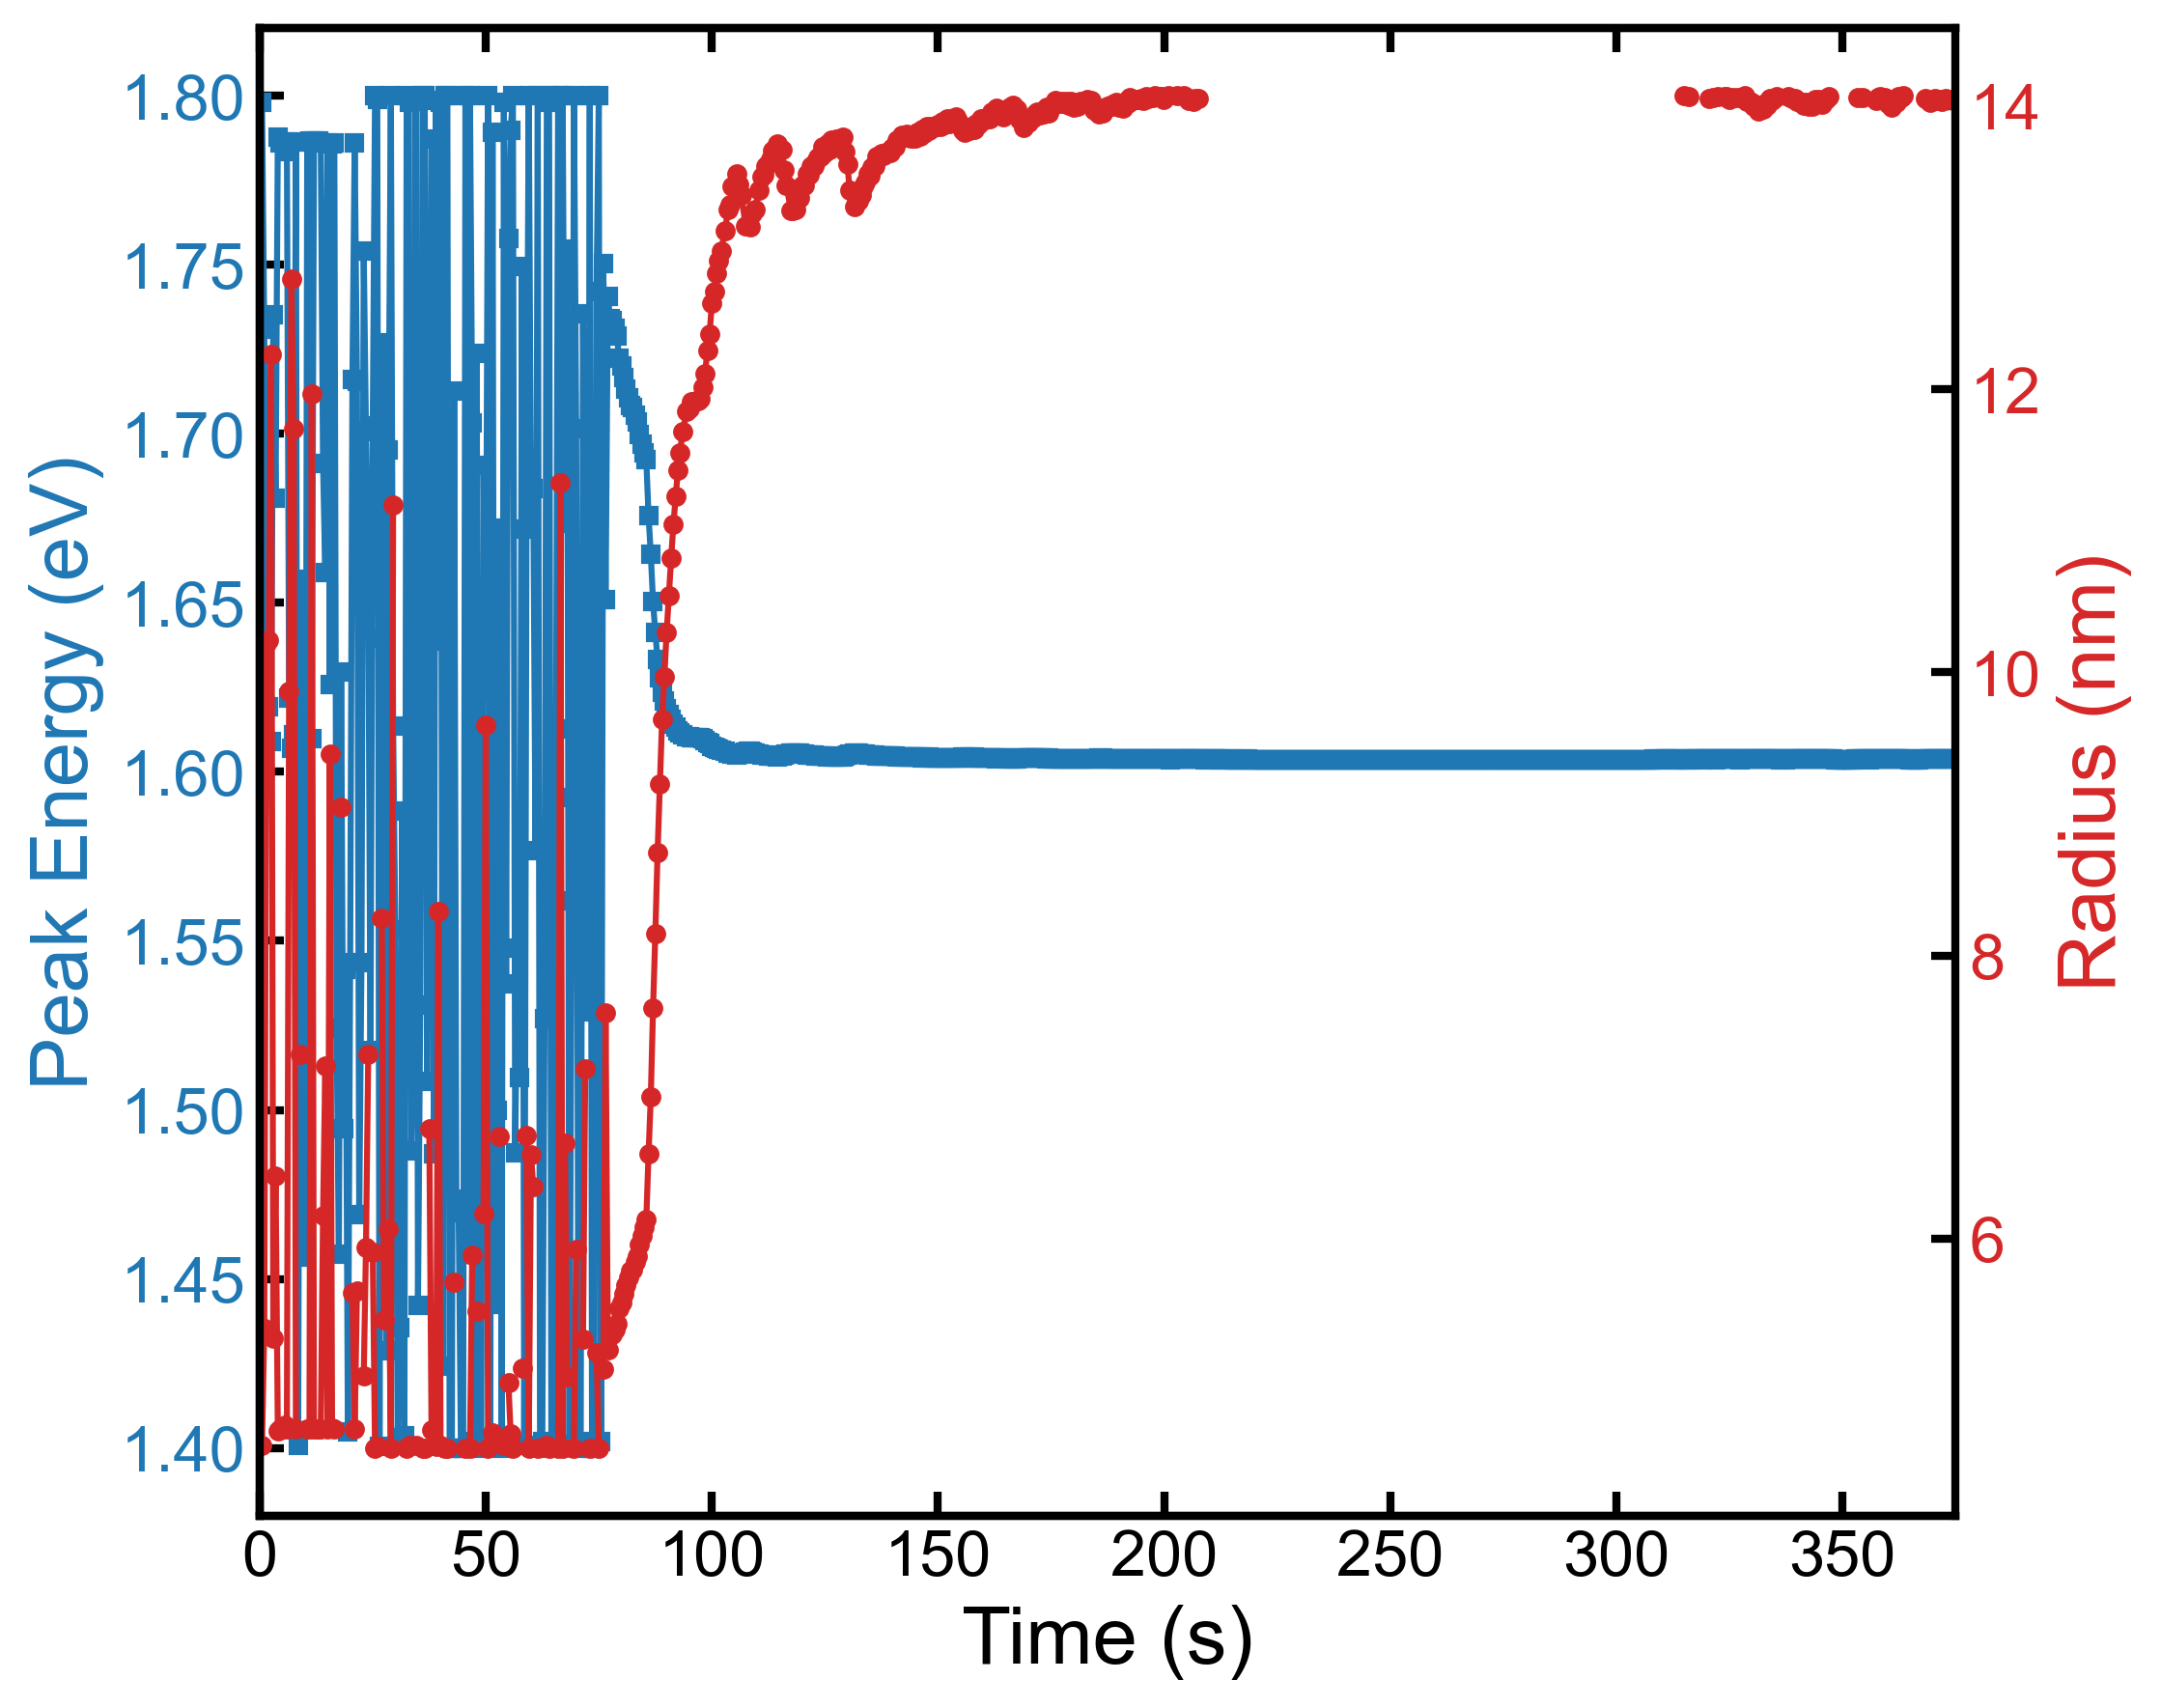

💾 Saved: E:\printz_Apr2024\MAPI_YL\working_files\MAPI_1pct_AVA_S1_18_30min\output\260114_Data\Peak Energy and Radius vs Time (no fitting)\260114_PL_FitResults_peak_energy_and_radius.png


In [7]:
# ==== Radius solver across batch (from peak shift) + plot (no fitting) ====

me_eff = me_star * m_e
mh_eff = mh_star * m_e
radius_bracket = (2e-10, 5e-8)  # 0.2 nm .. 50 nm

radius_results: Dict[str, pd.DataFrame] = {}

for name, s in batch.samples.items():
    df = s.df_clean.copy()
    tcol, pcol = s.time_column, s.peak_column

    for col in (tcol, pcol):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=[tcol, pcol])
    if df.empty:
        print(f"[WARN] '{name}' has no numeric time/peak rows. Skipping.")
        continue
    if skip_first and len(df) > 1:
        df = df.iloc[1:]

    # Reference "bulk" energy at time nearest target_time (or last)
    if target_time is not None and len(df) > 0:
        idx = (df[tcol] - target_time).abs().idxmin()
        Eg_bulk_eV = float(df.loc[idx, pcol])
    else:
        Eg_bulk_eV = float(df[pcol].iloc[-1])

    t = df[tcol].to_numpy()
    peak = df[pcol].to_numpy()

    radii_nm = []
    for Eg_meas_eV in peak:
        dE = Eg_meas_eV - Eg_bulk_eV
        if not np.isfinite(dE) or dE <= 0:
            radii_nm.append(np.nan)
            continue
        try:
            R_m = solve_radius_m(
                dE,
                me_eff,
                mh_eff,
                epsilon_pvk,
                epsilon_env,
                N=N_terms,
                bracket=radius_bracket,
            )
            radii_nm.append(R_m * 1e9)
        except Exception as err:
            print(f"[WARN] {name}: solve failed (ΔE={dE:.4g} eV): {err}")
            radii_nm.append(np.nan)

    radius_results[name] = pd.DataFrame(
        {
            "time_s": t,
            "peak_energy_eV": peak,
            "radius_nm": np.array(radii_nm, dtype=float),
        }
    )

# --- per-sample plot: Peak (blue, left) & Radius (red, right) WITHOUT fitting ---
export_dir = session.subdir("Peak Energy and Radius vs Time (no fitting)")
fs, tick_fs, marker_size = 20, 16, 4

saved = load_selected_files()
items = filter_items_by_saved(list(radius_results.items()), saved)

for name, d in items:
    if d.empty:
        continue
    t = d["time_s"].to_numpy()
    pk = d["peak_energy_eV"].to_numpy()
    rad = d["radius_nm"].to_numpy()

    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
    ax1.plot(
        t,
        pk,
        marker="s",
        markersize=marker_size,
        linestyle="-",
        color="tab:blue",
        label="Peak Energy",
    )
    ax1.set_xlabel("Time (s)", fontsize=fs, color="black")
    ax1.set_ylabel("Peak Energy (eV)", fontsize=fs, color="tab:blue")
    ax1.tick_params(
        axis="y",
        labelcolor="tab:blue",
        direction="in",
        labelsize=tick_fs,
        width=2,
        length=6,
        right=False,
    )
    ax1.tick_params(
        axis="x", direction="in", labelsize=tick_fs, width=2, length=6, top=True
    )
    ax1.spines["top"].set_visible(True)
    ax1.spines["right"].set_visible(False)
    for sp in ax1.spines.values():
        sp.set_linewidth(2)
        sp.set_color("black")
    if target_time is not None:
        ax1.set_xlim(0, target_time)
    ax1.xaxis.set_major_locator(ticker.MultipleLocator(50))

    ax2 = ax1.twinx()
    ax2.plot(
        t,
        rad,
        marker="o",
        markersize=marker_size,
        linestyle="-",
        color="tab:red",
        label="Radius",
    )
    ax2.set_ylabel("Radius (nm)", fontsize=fs, color="tab:red")
    ax2.tick_params(
        axis="y",
        labelcolor="tab:red",
        direction="in",
        labelsize=tick_fs,
        width=2,
        length=6,
        right=True,
    )
    for sp in ax2.spines.values():
        sp.set_linewidth(2)
        sp.set_color("black")

    finite = rad[np.isfinite(rad)]
    if finite.size:
        rmin, rmax = float(np.nanmin(finite)), float(np.nanmax(finite))
        pad = 0.05 * max(1e-12, abs(rmax - rmin))
        ax2.set_ylim(rmin - pad, rmax + pad)

    fig.tight_layout()
    fig.subplots_adjust(right=0.85)
    out_png = export_dir / f"{session.prefix}{name}_peak_energy_and_radius.png"
    plt.savefig(out_png, bbox_inches="tight")
    plt.show()
    print(f"💾 Saved: {out_png}")

# Peak & FWHM vs Time (Batch & Per-Sample) + Excel
Creates the dual-axis Peak/FWHM plots and exports underlying data.
- Batch overlay: all samples in one figure (Peak dotted, FWHM dashed).
- Per-sample figures with consistent styling.
- Computes a shared FWHM y-range (so solo plots match the batch scaling).
- Exports batch and per-sample Excel files with stacked data tables.


In [19]:
# === Peak & FWHM vs time (batch + per-sample, with Excel) ===
from itertools import cycle
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import cycle

_DATA_DIR_SAVEFILE = Path.cwd() / ".selected_data_dir.txt"


def _get_data_dir_strict() -> Path:
    # Prefer your Cell 2 function if present
    if "get_data_dir" in globals():
        try:
            p = Path(get_data_dir())
            if p.exists() and p.is_dir():
                return p
        except Exception:
            pass
    # Otherwise read the persisted file from Cell 2
    if _DATA_DIR_SAVEFILE.exists():
        p = Path(_DATA_DIR_SAVEFILE.read_text().strip())
        if p.exists() and p.is_dir():
            return p
        raise FileNotFoundError(
            f"Saved data_dir is invalid: {p}. Re-run Cell 2 to reselect."
        )
    raise RuntimeError(
        "No saved data_dir found. Re-run Cell 2 to pick the parent data folder."
    )


def _ensure_data_dir(subdir: str | None = None) -> Path:
    """Return <data_dir>/<YYMMDD>_Data[/<subdir>] (creates it if needed)."""
    base = _get_data_dir_strict()
    day = datetime.now().strftime("%y%m%d")
    root = base / f"{day}_Data"
    if subdir:
        root = root / subdir
    root.mkdir(parents=True, exist_ok=True)
    return root


def _date_prefix() -> str:
    return datetime.now().strftime("%y%m%d_")


if "_ensure_data_dir" not in globals():

    def _ensure_data_dir(subdir: str | None = None) -> Path:
        """Return <data_dir>/<YYMMDD>_Data[/<subdir>] and create it if needed."""
        try:
            base = Path(get_data_dir())
        except Exception:
            base = Path.cwd()
        day = datetime.now().strftime("%y%m%d")
        root = base / f"{day}_Data"
        if subdir:
            root = root / subdir
        root.mkdir(parents=True, exist_ok=True)
        return root


if "_date_prefix" not in globals():

    def _date_prefix() -> str:
        return datetime.now().strftime("%y%m%d_")


# Selection helpers (if not already defined earlier)
if "_load_saved_selected_files" not in globals():
    _SELECTED_FILES_SAVEFILE = Path.cwd() / ".selected_files.txt"

    def _load_saved_selected_files():
        if not _SELECTED_FILES_SAVEFILE.exists():
            return []
        lines = [
            ln.strip()
            for ln in _SELECTED_FILES_SAVEFILE.read_text().splitlines()
            if ln.strip()
        ]
        paths = [Path(ln) for ln in lines]
        return [p.resolve() for p in paths if p.exists() and p.is_file()]


if "_find_sample_source_path" not in globals():

    def _find_sample_source_path(sample_obj):
        for attr in (
            "source_path",
            "filepath",
            "file_path",
            "path",
            "file",
            "filename",
            "source",
        ):
            if hasattr(sample_obj, attr):
                p = getattr(sample_obj, attr)
                if p is not None:
                    try:
                        return Path(p)
                    except Exception:
                        pass
        return None


if "_should_include_sample" not in globals():

    def _should_include_sample(sample_name: str, sample_obj, selected_files):
        if not selected_files:
            return True
        selected_names = {p.name.lower() for p in selected_files}
        selected_stems = {p.stem.lower() for p in selected_files}
        src = _find_sample_source_path(sample_obj)
        if src is not None:
            src = Path(src)
            if src.name.lower() in selected_names or src.stem.lower() in selected_stems:
                return True
        if isinstance(sample_name, str) and sample_name.lower() in selected_stems:
            return True
        if hasattr(sample_obj, "name") and isinstance(sample_obj.name, str):
            if sample_obj.name.lower() in selected_stems:
                return True
        return False


def _shared_fwhm_ylim(items, skip_first=True):
    fmin, fmax = np.inf, -np.inf
    for name, s in items:
        df = s.df_clean.copy()
        tcol, pcol, fcol = s.time_column, s.peak_column, s.fwhm_column
        # ensure numeric
        for col in (tcol, pcol, fcol):
            if not pd.api.types.is_numeric_dtype(df[col]):
                df[col] = pd.to_numeric(df[col], errors="coerce")
        df = df.dropna(subset=[tcol, pcol, fcol])
        if skip_first and len(df) > 1:
            df = df.iloc[1:]
        if df.empty:
            continue
        vals = df[fcol].to_numpy()
        fmin = min(fmin, float(np.nanmin(vals)))
        fmax = max(fmax, float(np.nanmax(vals)))
    if not np.isfinite(fmin) or not np.isfinite(fmax):
        return (0.0, 1.0)
    pad = 0.05 * max(1e-12, abs(fmax - fmin))
    ymin, ymax = fmin - pad, fmax + pad
    if np.isclose(ymin, ymax):
        ymin -= 0.1 * (abs(ymin) + 1.0)
        ymax += 0.1 * (abs(ymax) + 1.0)
    return (ymin, ymax)


# Pull global knobs if present
x_locator_val = globals().get("x_locator", 50)
target_time_val = globals().get("target_time", None)
skip_first_val = globals().get("skip_first", True)

# Export dir + prefix
export_dir = _ensure_data_dir("Peak Position and FWHM vs Time")
prefix = _date_prefix()

# Items (respect previously saved file selection if present)
active_selection = []
try:
    active_selection = _load_saved_selected_files()
except Exception:
    active_selection = []

items = list(batch.samples.items())
if active_selection:
    items = [
        (n, s)
        for n, s in batch.samples.items()
        if _should_include_sample(n, s, active_selection)
    ]
    print(
        f"ℹ️ Filtering to {len(items)} of {len(batch.samples)} samples "
        f"based on {len(active_selection)} saved selected file(s)."
    )
else:
    print("ℹ️ No saved file selection; using all samples.")

# ---------- Batch overlay ----------
colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()
    .get("color", ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"])
)
cyc = cycle(colors)

fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
ax2 = ax1.twinx()

rows = []
any_points = False
g_tmin, g_tmax = np.inf, -np.inf
g_pmin, g_pmax = np.inf, -np.inf

for name, s in items:
    df = s.df_clean.copy()
    tcol, pcol, fcol = s.time_column, s.peak_column, s.fwhm_column
    for col in (tcol, pcol, fcol):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=[tcol, pcol, fcol])
    if skip_first_val and len(df) > 1:
        df = df.iloc[1:]
    if df.empty:
        continue

    t = df[tcol].to_numpy()
    peak = df[pcol].to_numpy()
    fwhm = df[fcol].to_numpy()

    c = next(cyc)
    # Peak dotted; FWHM dashed — matches your earlier style
    ax1.plot(t, peak, linestyle=":", marker=None, color=c, label=f"{name} Peak")
    ax2.plot(t, fwhm, linestyle="--", marker=None, color=c, label=f"{name} FWHM")
    any_points = True

    g_tmin, g_tmax = min(g_tmin, float(t.min())), max(g_tmax, float(t.max()))
    g_pmin, g_pmax = min(g_pmin, float(peak.min())), max(g_pmax, float(peak.max()))

    rows.append(
        pd.DataFrame({"sample": name, "time_s": t, "peak_eV": peak, "fwhm": fwhm})
    )

if not any_points:
    raise ValueError("No data found to plot (after filtering).")

# Labels & styling
ax1.set_ylabel(
    "Peak Position (eV)", color="black", fontsize=24, fontname="Arial", labelpad=10
)
ax1.tick_params(
    axis="y",
    labelcolor="black",
    direction="in",
    width=2,
    length=6,
    labelsize=20,
    right=False,
)
ax1.set_xlabel("Time (s)", fontsize=24, fontname="Arial", color="black", labelpad=10)
ax1.tick_params(
    axis="x", direction="in", width=2, length=6, labelsize=20, color="black", top=True
)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(x_locator_val))
for sp in ax1.spines.values():
    sp.set_linewidth(2)
    sp.set_color("black")
ax1.spines["top"].set_visible(True)
ax1.spines["right"].set_visible(False)

# Peak axis y-lims with padding
peak_pad = 0.02 * max(1e-12, abs(g_pmax - g_pmin))
ax1.set_ylim(g_pmin - peak_pad, g_pmax + peak_pad)

# Shared FWHM limits (correct usage)
fwhm_y0, fwhm_y1 = _shared_fwhm_ylim(items, skip_first=skip_first_val)
ax2.set_ylabel("FWHM", color="black", fontsize=20, fontname="Arial", labelpad=10)
ax2.tick_params(
    axis="y",
    labelcolor="black",
    direction="in",
    width=2,
    length=6,
    labelsize=20,
    right=True,
)
for sp in ax2.spines.values():
    sp.set_linewidth(2)
    sp.set_color("black")
ax2.set_ylim(fwhm_y0, fwhm_y1)

# X limits
if target_time_val is not None:
    ax1.set_xlim(0, target_time_val)
    ax2.set_xlim(0, target_time_val)
else:
    ax1.set_xlim(g_tmin, g_tmax)
    ax2.set_xlim(g_tmin, g_tmax)

# Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg = ax1.legend(h1 + h2, l1 + l2, loc="best", frameon=False)
for ttxt in leg.get_texts():
    ttxt.set_fontname("Arial")
    ttxt.set_color("black")
    ttxt.set_fontsize(12)

plt.tight_layout()
fig.subplots_adjust(right=0.85)
fig_path = export_dir / f"{prefix}peak_fwhm_plot.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.close(fig)

print(f"💾 Figure saved: {fig_path}")


# ---------- Per-sample PNG + XLSX (uses same shared FWHM limits) ----------
for name, s in items:
    df = s.df_clean.copy()
    tcol, pcol, fcol = s.time_column, s.peak_column, s.fwhm_column
    for col in (tcol, pcol, fcol):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=[tcol, pcol, fcol])
    if skip_first_val and len(df) > 1:
        df = df.iloc[1:]
    if df.empty:
        print(f"[WARN] No valid numeric rows for sample '{name}'. Skipping.")
        continue

    t = df[tcol].to_numpy()
    peak = df[pcol].to_numpy()
    fwhm = df[fcol].to_numpy()

    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
    ax2 = ax1.twinx()

    # Curves
    ax1.plot(t, peak, marker="s", linestyle="-", color="tab:blue", label="Peak")
    ax2.plot(t, fwhm, marker="o", linestyle="-", color="tab:green", label="FWHM")

    # Left axis (Peak)
    ax1.set_ylabel(
        "Peak Position (eV)",
        color="tab:blue",
        fontsize=24,
        fontname="Arial",
        labelpad=10,
    )
    ax1.tick_params(
        axis="y", labelcolor="tab:blue", direction="in", width=2, length=6, labelsize=20
    )

    # X axis
    ax1.set_xlabel(
        "Time (s)", fontsize=24, fontname="Arial", color="black", labelpad=10
    )
    ax1.tick_params(
        axis="x",
        direction="in",
        width=2,
        length=6,
        labelsize=20,
        color="black",
        top=True,
    )
    ax1.xaxis.set_major_locator(ticker.MultipleLocator(x_locator_val))
    for sp in ax1.spines.values():
        sp.set_linewidth(2)
    ax1.spines["top"].set_visible(True)
    ax1.spines["right"].set_visible(False)

    # Peak y-lims (per-sample pad)
    pad = 0.02 * max(1e-12, float(peak.max() - peak.min()))
    ax1.set_ylim(float(peak.min() - pad), float(peak.max() + pad))

    # Right axis (FWHM) — shared limits
    ax2.set_ylabel(
        "FWHM", color="tab:green", fontsize=20, fontname="Arial", labelpad=10
    )
    ax2.tick_params(
        axis="y",
        labelcolor="tab:green",
        direction="in",
        width=2,
        length=6,
        labelsize=20,
    )
    for sp in ax2.spines.values():
        sp.set_linewidth(2)
    ax2.set_ylim(fwhm_y0, fwhm_y1)

    # X limits
    if target_time_val is not None:
        ax1.set_xlim(0, target_time_val)
        ax2.set_xlim(0, target_time_val)

    # Legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    leg = ax1.legend(h1 + h2, l1 + l2, loc="best", frameon=False)
    for ttxt in leg.get_texts():
        ttxt.set_fontname("Arial")
        ttxt.set_fontsize(14)

    plt.tight_layout()
    fig.subplots_adjust(right=0.85)

    # Save PNG + XLSX
    png_path = export_dir / f"{prefix}{name}_peak_fwhm.png"
    plt.savefig(png_path, bbox_inches="tight")
    plt.close(fig)

    print(f"💾 Saved: {png_path}")

ℹ️ Filtering to 7 of 7 samples based on 7 saved selected file(s).
💾 Figure saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Peak Position and FWHM vs Time\260106_peak_fwhm_plot.png
💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Peak Position and FWHM vs Time\260106_PL_FitResults_1pct_ABA_peak_fwhm.png
💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Peak Position and FWHM vs Time\260106_PL_FitResults_1pct_AHA_peak_fwhm.png
💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Peak Position and FWHM vs Time\260106_PL_FitResults_1pct_APA_peak_fwhm.png
💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Peak Position and FWHM vs Time\260106_PL_FitResults_1pct_AVA_peak_fwhm.png
💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Peak Position and FWHM vs Time\260106_PL_FitResults_1pct_AVACl_peak_fwhm.png
💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Peak Position and FWHM vs Time\260106_PL_FitResults_1pct_AVAI_peak_fwhm.png
💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\P

# Interactive Region Fitter (Plotly Clicks → Matplotlib Export)
Define 3 time boundaries by clicking; fit radius segments to single-exp decays.
- Click **3 times**: start R1, end R1/start R2, end R2/start R3.
- Fits each region: `r(t) = A·e^(−t/τ) + C`, reports **R²**.
- Exports:
  - PNG with Peak/Radius and dashed fit curves + equation block,
  - Excel with `Fit_Parameters` (A, τ, C, R² + absolute dashed bounds) and `Raw_Data`.
- Saved files feed the growth-rate and Word-report cells.


In [20]:
# =========================
# Interactive Region Fitter — Plotly clicks, Matplotlib export
# =========================
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

import plotly.graph_objects as go
from IPython.display import display, clear_output
import ipywidgets as widgets

# ---------- Shared path helpers (self-contained) ----------
_DATA_DIR_SAVEFILE = Path.cwd() / ".selected_data_dir.txt"


def _get_data_dir_strict() -> Path:
    """Return the data_dir chosen in the picker (or the saved fallback)."""
    if "get_data_dir" in globals():
        try:
            p = Path(get_data_dir())
            if p.exists() and p.is_dir():
                return p
        except Exception:
            pass
    if _DATA_DIR_SAVEFILE.exists():
        p = Path(_DATA_DIR_SAVEFILE.read_text().strip())
        if p.exists() and p.is_dir():
            return p
        raise FileNotFoundError(
            f"Saved data_dir is invalid: {p}. Re-run the folder picker."
        )
    raise RuntimeError("No saved data_dir found. Re-run the folder picker cell.")


def _day_root() -> Path:
    """<data_dir>/<YYMMDD>_Data"""
    day = datetime.now().strftime("%y%m%d")
    root = _get_data_dir_strict() / f"{day}_Data"
    root.mkdir(parents=True, exist_ok=True)
    return root


def _ensure_day_subdir(name: str) -> Path:
    """Ensure a subfolder under <data_dir>/<YYMMDD>_Data and return it."""
    out = _day_root() / name
    out.mkdir(parents=True, exist_ok=True)
    return out


def _date_prefix() -> str:
    """Return 'YYMMDD_' prefix for filenames."""
    return datetime.now().strftime("%y%m%d_")


# ---------- CONFIG ----------
MIN_POINTS = 15
NOISE_THRESHOLD = globals().get("NOISE_THRESHOLD", 0)
marker_size = 4
fs, tick_fs = 20, 16
X_MAJOR_STEP = 50
BLUE = "#1f77b4"  # tab:blue
ORANGE = "#d62728"  # red/orange style for radius
prefix = _date_prefix()

# ---------- Selection filter (optional) ----------
_SELECTED_FILES_SAVEFILE = Path.cwd() / ".selected_files.txt"


def _load_saved_selected_files() -> list[Path]:
    if not _SELECTED_FILES_SAVEFILE.exists():
        return []
    lines = [
        ln.strip()
        for ln in _SELECTED_FILES_SAVEFILE.read_text().splitlines()
        if ln.strip()
    ]
    paths = [Path(ln) for ln in lines]
    return [p.resolve() for p in paths if p.exists() and p.is_file()]


def _filter_names_by_saved(all_items):
    saved = _load_saved_selected_files()
    if not saved:
        print("ℹ️ No saved file selection found; analyzing all datasets.")
        return all_items
    stems = {p.stem.lower() for p in saved}
    keep = [(n, d) for n, d in all_items if isinstance(n, str) and n.lower() in stems]
    print(
        f"ℹ️ Using {len(keep)} of {len(all_items)} datasets based on previously selected files."
    )
    if not keep:
        raise RuntimeError("No datasets matched the previously selected files.")
    return keep


# ---------- Model & helpers ----------
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C


def _align_bounds(bounds):
    if not bounds:
        return []
    aligned = [(float(bounds[0][0]), float(bounds[0][1]))]
    for k in range(1, len(bounds)):
        prev_end = aligned[k - 1][1]
        end_k = float(bounds[k][1])
        start_k = float(prev_end)
        end_k = max(end_k, start_k)
        aligned.append((start_k, end_k))
    return aligned


def _indices_from_bounds_strict(t, start_time, end_time, prev_end_idx=0):
    n = len(t)
    i0 = np.searchsorted(t, start_time, side="left")
    i1 = np.searchsorted(t, end_time, side="right")
    i0 = max(i0, prev_end_idx)
    i0 = max(0, min(i0, n))
    i1 = max(i0, min(i1, n))
    return i0, i1


def fit_region_single_exp(t_seg, r_seg, region_idx):
    if len(t_seg) < MIN_POINTS:
        return None
    if region_idx in (1, 2):
        C0 = float(np.nanmin(r_seg)) if np.isfinite(r_seg).any() else 0.0
    else:
        C0 = -1.0
    p0 = [1.0, 50.0, C0]

    m = np.isfinite(t_seg) & np.isfinite(r_seg)
    t_clean = t_seg[m]
    r_clean = r_seg[m]
    if len(t_clean) < MIN_POINTS:
        return None

    params, _ = curve_fit(
        exp_decay, t_clean, r_clean, p0=p0, bounds=(-np.inf, np.inf), maxfev=20000
    )
    A, tau, C = [float(x) for x in params]

    residuals = r_clean - exp_decay(t_clean, A, tau, C)
    ss_res = float(np.sum(residuals**2))
    ss_tot = float(np.sum((r_clean - np.mean(r_clean)) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else -np.inf

    r_fit = exp_decay(t_seg, A, tau, C)
    return A, tau, C, r2, r_fit


# --- Fast display helpers for Plotly FigureWidget ---
def decimate_for_display(x, y, max_points=5000):
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)
    if n <= max_points:
        return x, y
    idx = np.linspace(0, n - 1, max_points).astype(int)
    return x[idx], y[idx]


# ---------- Plotly click UI (square) ----------
def show_click_picker_fast(name, t, peak, rad, target_time=None, max_points=5000):
    t_full = np.asarray(t, dtype=float)
    tmax = float(target_time if target_time is not None else t_full[-1])

    t_ds, peak_ds = decimate_for_display(t_full, peak, max_points=max_points)
    _, rad_ds = decimate_for_display(t_full, rad, max_points=max_points)

    finite_rad = np.asarray(rad, dtype=float)
    finite_rad = finite_rad[np.isfinite(finite_rad)]
    if finite_rad.size:
        rmin, rmax = float(finite_rad.min()), float(finite_rad.max())
        pad = 0.05 * max(1e-12, abs(rmax - rmin))
        y2_range = [rmin - pad, rmax + pad]
    else:
        y2_range = [0, 20]

    fig = go.FigureWidget()
    fig.update_layout(clickmode="event+select")

    fig.add_trace(
        go.Scattergl(
            x=t_ds,
            y=peak_ds,
            mode="lines+markers",
            name="Peak Energy (eV)",
            line=dict(width=2, color=BLUE),
            marker=dict(size=6, color=BLUE),
        )
    )
    fig.add_trace(
        go.Scattergl(
            x=t_ds,
            y=rad_ds,
            mode="lines+markers",
            name="Radius (nm)",
            line=dict(width=2, color=ORANGE),
            marker=dict(size=6, color=ORANGE),
            yaxis="y2",
        )
    )

    tick_size = 16
    title_size = 20
    fig.update_layout(
        title=dict(text=name, font=dict(size=22, color="black")),
        xaxis=dict(
            title=dict(
                text="Time (s)", font=dict(size=int(title_size * 1.75), color="black")
            ),
            range=[0, tmax],
            showgrid=False,
            zeroline=False,
            ticks="inside",
            ticklen=6,
            tickwidth=2,
            tickcolor="black",
            showline=True,
            linecolor="black",
            linewidth=2,
            tickfont=dict(size=int(tick_size * 1.5), color="black"),
        ),
        yaxis=dict(
            title=dict(
                text="Peak Energy (eV)",
                font=dict(size=int(title_size * 1.75), color=BLUE),
            ),
            showgrid=False,
            zeroline=False,
            ticks="inside",
            ticklen=6,
            tickwidth=2,
            tickcolor=BLUE,
            showline=True,
            linecolor=BLUE,
            linewidth=2,
            tickfont=dict(size=int(tick_size * 1.5), color=BLUE),
        ),
        yaxis2=dict(
            title=dict(
                text="Radius (nm)", font=dict(size=int(title_size * 1.75), color=ORANGE)
            ),
            overlaying="y",
            side="right",
            range=y2_range,
            showgrid=False,
            zeroline=False,
            ticks="inside",
            ticklen=6,
            tickwidth=2,
            tickcolor=ORANGE,
            showline=True,
            linecolor=ORANGE,
            linewidth=2,
            tickfont=dict(size=int(tick_size * 1.5), color=ORANGE),
        ),
        showlegend=False,
        template=None,
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=800,
        height=800,
        margin=dict(l=120, r=90, t=80, b=80),
        uirevision=name,
        shapes=[],
    )

    clicks = []
    status = widgets.HTML(
        "<b>Click 3 times:</b> start R1, end R1/start R2, end R2/start R3"
    )
    run_btn = widgets.Button(description="Run Fits", button_style="primary")
    undo_btn = widgets.Button(description="Undo last", button_style="")
    clear_btn = widgets.Button(description="Clear", button_style="warning")
    out = widgets.Output()

    def _redraw_vlines():
        fig.layout.shapes = tuple(
            dict(
                type="line",
                xref="x",
                yref="paper",
                x0=x,
                x1=x,
                y0=0,
                y1=1,
                line=dict(color="black", width=1.5, dash="dot"),
            )
            for x in clicks
        )

    t_arr = np.asarray(t_full, dtype=float)

    def _on_click(trace, points, state):
        if not points.xs or len(clicks) >= 3:
            return
        x_raw = float(points.xs[0])
        x_raw = max(0.0, min(x_raw, tmax))
        x = float(t_arr[np.argmin(np.abs(t_arr - x_raw))])
        if clicks and abs(x - clicks[-1]) < 1e-12:
            return
        clicks.append(x)
        clicks.sort()
        _redraw_vlines()
        status.value = f"<b>{len(clicks)}/3</b> clicks. Last x = {x:.3f}s"

    for tr in fig.data:
        tr.on_click(_on_click)

    def _undo(_):
        if clicks:
            clicks.pop()
            _redraw_vlines()
            status.value = f"Undo. {len(clicks)}/3 clicks."

    def _clear(_):
        clicks.clear()
        _redraw_vlines()
        status.value = "Cleared. 0/3 clicks."

    undo_btn.on_click(_undo)
    clear_btn.on_click(_clear)

    ui = widgets.VBox(
        [
            widgets.HTML(f"<h3>{name}</h3>"),
            status,
            widgets.HBox([undo_btn, clear_btn, run_btn]),
            fig,
        ]
    )

    return fig, ui, run_btn, out, clicks, tmax


# ---------- In-memory store for fits ----------
def _store_fit_results_in_memory(name, t0, peak_f, rad_f, t0_offset, regions):
    """
    Store fitted regions in global FIT_MODELS and raw series in FIT_RAW.
    """
    model = {"t0_offset": float(t0_offset), "regions": []}
    for seg_t0, seg_r, fit in regions:
        if fit is None or len(seg_t0) == 0:
            model["regions"].append(
                {
                    "A": np.nan,
                    "tau": np.nan,
                    "C": np.nan,
                    "R2": np.nan,
                    "t_start_norm": np.nan,
                    "t_end_norm": np.nan,
                    "t_start_abs": np.nan,
                    "t_end_abs": np.nan,
                    "f_norm": None,
                    "df_norm": None,
                    "f_abs": None,
                    "df_abs": None,
                }
            )
            continue

        A, tau, C, r2, _yfit = fit
        t_start_norm = float(seg_t0[0])
        t_end_norm = float(seg_t0[-1])
        t_start_abs = t_start_norm + t0_offset
        t_end_abs = t_end_norm + t0_offset

        # callable functions
        f_norm = (lambda A=A, tau=tau, C=C: (lambda t: A * np.exp(-t / tau) + C))()
        df_norm = (lambda A=A, tau=tau: (lambda t: -(A / tau) * np.exp(-t / tau)))()
        f_abs = (
            lambda A=A, tau=tau, C=C, t0=t0_offset: (
                lambda t_abs: A * np.exp(-(t_abs - t0) / tau) + C
            )
        )()
        df_abs = (
            lambda A=A, tau=tau, t0=t0_offset: (
                lambda t_abs: -(A / tau) * np.exp(-(t_abs - t0) / tau)
            )
        )()

        model["regions"].append(
            {
                "A": float(A),
                "tau": float(tau),
                "C": float(C),
                "R2": float(r2),
                "t_start_norm": t_start_norm,
                "t_end_norm": t_end_norm,
                "t_start_abs": t_start_abs,
                "t_end_abs": t_end_abs,
                "f_norm": f_norm,
                "df_norm": df_norm,
                "f_abs": f_abs,
                "df_abs": df_abs,
            }
        )

    if "FIT_MODELS" not in globals() or not isinstance(
        globals().get("FIT_MODELS"), dict
    ):
        globals()["FIT_MODELS"] = {}
    globals()["FIT_MODELS"][name] = model

    # Optional: retain raw
    if "FIT_RAW" not in globals() or not isinstance(globals().get("FIT_RAW"), dict):
        globals()["FIT_RAW"] = {}
    globals()["FIT_RAW"][name] = pd.DataFrame(
        {
            "Time_rel (s)": t0,
            "Time_abs (s)": t0 + t0_offset,
            "Peak Energy (eV)": peak_f,
            "Radius (nm)": rad_f,
        }
    )


# ---------- Core: fit, plot, export (Matplotlib) ----------
def _fit_and_plot(
    name, t0, peak_f, rad_f, bounds, target_time, outdir_unused, t0_offset
):
    # Fit each region
    regions = []
    prev_end_idx = 0
    for k, (start, end) in enumerate(bounds, start=1):
        i_start, i_end = _indices_from_bounds_strict(
            t0, start, end, prev_end_idx=prev_end_idx
        )
        while i_start < i_end and t0[i_start] < start:
            i_start += 1
        seg_t0 = t0[i_start:i_end]
        seg_r = rad_f[i_start:i_end]
        fit = fit_region_single_exp(seg_t0, seg_r, region_idx=k)
        regions.append((seg_t0, seg_r, fit))
        prev_end_idx = i_start + len(seg_t0)

    # Matplotlib figure — styled like earlier
    fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
    ax1.plot(
        t0, peak_f, marker="s", markersize=marker_size, color=BLUE, label="Peak Energy"
    )
    ax1.set_xlabel("Time (s)", fontsize=fs, fontname="Arial", color="black")
    ax1.set_ylabel("Peak Energy (eV)", fontsize=fs, fontname="Arial", color=BLUE)
    ax1.grid(False)
    ax1.tick_params(
        axis="x",
        direction="in",
        top=True,
        width=2,
        length=6,
        labelsize=tick_fs,
        labelcolor="black",
    )
    ax1.tick_params(
        axis="y",
        direction="in",
        width=2,
        length=6,
        labelsize=tick_fs,
        labelcolor=BLUE,
        right=False,
    )
    for sp in ax1.spines.values():
        sp.set_linewidth(2)
        sp.set_color("black")
    ax1.spines["top"].set_visible(True)
    ax1.spines["right"].set_visible(False)
    if target_time is not None:
        ax1.set_xlim(0, target_time)
    ax1.xaxis.set_major_locator(ticker.MultipleLocator(X_MAJOR_STEP))
    ax1.locator_params(axis="y", nbins=5)

    ax2 = ax1.twinx()
    ax2.plot(
        t0, rad_f, marker="o", markersize=marker_size, color=ORANGE, label="Radius"
    )
    ax2.set_ylabel("Radius (nm)", fontsize=fs, fontname="Arial", color=ORANGE)
    ax2.tick_params(
        axis="y",
        labelcolor=ORANGE,
        direction="in",
        width=2,
        length=6,
        labelsize=tick_fs,
    )
    for sp in ax2.spines.values():
        sp.set_linewidth(2)
        sp.set_color("black")
    if np.isfinite(rad_f).any():
        rmin, rmax = np.nanmin(rad_f), np.nanmax(rad_f)
        pad = 0.05 * max(1e-12, abs(rmax - rmin))
        ax2.set_ylim(rmin - pad, rmax + pad)
    else:
        ax2.set_ylim(0, 20)
    ax2.locator_params(axis="y", nbins=5)

    # Draw dashed fits (black) and gather equation lines
    eq_lines = []
    prev_dashed_end_norm = None
    for idx, (seg_t0, _, fit) in enumerate(regions, start=1):
        label = f"Reg {idx}: "
        if fit is None or len(seg_t0) == 0:
            eq_lines.append(rf"\mathrm{{{label}}}\ \text{{(not fit)}}")
            continue
        A, tau, C, r2, yfit = fit
        tt, yy = seg_t0.copy(), yfit.copy()
        # continuity
        if prev_dashed_end_norm is not None and not np.isnan(prev_dashed_end_norm):
            if len(tt) == 0 or tt[0] > prev_dashed_end_norm + 1e-12:
                tt = np.concatenate(([prev_dashed_end_norm], tt))
                yy = np.concatenate(
                    (exp_decay(np.array([prev_dashed_end_norm]), A, tau, C), yy)
                )
            else:
                tt[0] = prev_dashed_end_norm
        prev_dashed_end_norm = float(tt[-1]) if len(tt) else prev_dashed_end_norm
        ax2.plot(tt, yy, "--", color="black", lw=1.5)
        eq_lines.append(
            rf"\mathrm{{{label}}} \ r(t)= {A:.3g}\,e^{{-t/{tau:.3g}}}+{C:.3g}\quad R^2={r2:.3f}"
        )

    # Equation text block on right axis
    eq_text = (
        "\n".join([f"${line}$" for line in eq_lines])
        if eq_lines
        else r"$\text{No fits.}$"
    )
    y_min, y_max = ax2.get_ylim()
    y_target = 6.0
    y_text_top = min(
        max(y_target, y_min + 0.01 * (y_max - y_min)), y_max - 0.01 * (y_max - y_min)
    )
    from matplotlib.transforms import blended_transform_factory

    trans = blended_transform_factory(ax2.transAxes, ax2.transData)
    ax2.text(
        0.35,
        y_text_top,
        eq_text,
        transform=trans,
        ha="left",
        va="top",
        fontsize=11,
        color="black",
        fontname="Arial",
    )

    plt.tight_layout()

    # ✅ Save under parent/day folder
    outdir = _ensure_day_subdir("Peak Energy and Radius vs Time (fitting)")
    out_png = outdir / f"{_date_prefix()}{name}_fit_regions.png"
    plt.savefig(out_png, bbox_inches="tight")
    plt.show()
    print(f"Saved {out_png}")

    # ✅ Store in memory (no XLSX export here)
    _store_fit_results_in_memory(name, t0, peak_f, rad_f, t0_offset, regions)
    print(f"✓ In-memory fits stored for '{name}'.")


# ---------- Per-dataset driver ----------
def run_one_dataset(name, d, target_time=None, bounds=None):
    # Sort by time
    t_all = d["time_s"].to_numpy().flatten()
    peak_all = d["peak_energy_eV"].to_numpy().flatten()
    rad_all = d["radius_nm"].to_numpy().flatten()
    order = np.argsort(t_all)
    t_all, peak_all, rad_all = t_all[order], peak_all[order], rad_all[order]

    # Filter
    m = np.isfinite(t_all) & (t_all > NOISE_THRESHOLD) & np.isfinite(rad_all)
    t_f, peak_f, rad_f = t_all[m], peak_all[m], rad_all[m]
    if len(t_f) < 3 * MIN_POINTS:
        print(f"[WARN] {name}: not enough valid points after filtering.")
        return

    # Normalize time
    t0_offset = float(t_f[0])
    t0 = t_f - t0_offset
    t0_max = float(t0[-1])

    # If explicit absolute bounds provided, convert to normalized
    chosen_bounds = None
    if bounds is not None:
        bounds_norm = [
            (float(a - t0_offset), float(b - t0_offset)) for (a, b) in bounds
        ]
        chosen_bounds = _align_bounds(bounds_norm)

    if chosen_bounds is None:
        # Plotly click UI
        fig, ui_box, run_btn, out, clicks, tmax = show_click_picker_fast(
            name,
            t0,
            peak_f,
            rad_f,
            target_time if target_time is not None else t0_max,
            max_points=5000,
        )
        display(ui_box, out)

        def _run(_):
            with out:
                clear_output()
                if len(clicks) < 3:
                    print(
                        "Please click 3 times to define region boundaries before running fits."
                    )
                    return
                c1, c2, c3 = sorted(clicks)[:3]
                chosen = _align_bounds([(c1, c2), (c2, c3), (c3, tmax)])
                _fit_and_plot(
                    name,
                    t0,
                    peak_f,
                    rad_f,
                    chosen,
                    target_time if target_time is not None else t0_max,
                    None,
                    t0_offset,
                )

        run_btn.on_click(_run)
        return

    # Non-UI path: run immediately
    _fit_and_plot(
        name,
        t0,
        peak_f,
        rad_f,
        chosen_bounds,
        target_time if target_time is not None else t0_max,
        None,
        t0_offset,
    )


# ---------- Batch driver ----------
def analyze_radius_results(radius_results, target_time=None):
    if not isinstance(radius_results, dict) or not radius_results:
        print("[ERROR] radius_results is not a non-empty dict.")
        return
    items = _filter_names_by_saved(list(radius_results.items()))
    for name, d in items:
        if not isinstance(d, pd.DataFrame) or d.empty:
            print(f"[WARN] {name}: empty or invalid DataFrame; skipping.")
            continue
        run_one_dataset(name, d, target_time=target_time)


# ---------- Auto-run if inputs present ----------
if "radius_results" in globals():
    analyze_radius_results(
        radius_results, target_time=globals().get("target_time", None)
    )
else:
    print("[ERROR] radius_results not found. Run your loader first.")

ℹ️ Using 7 of 7 datasets based on previously selected files.


Output()

Output()

Output()

Output()

Output()

Output()

Output()

# Growth-rate plotting (dr/dt) from saved `FIT_MODELS`

This cell renders **radius growth rate vs time** (`dr/dt`) using the exponential fits saved earlier and taking the derivatives of them.

### What it does
1. **Overlay plot (all datasets)**  
   Iterates all datasets & their regions; for each valid region:
   - picks bounds based on `TIME_MODE`
   - evaluates \(dr/dt\) on a linspace grid
   - plots dashed curves (one color per dataset; legend shows dataset once)
   - saves **`YYMMDD_Data/Radius Growth Rate vs Time/YYMMDD_ALL_DATASETS_growth_rate.png`**

2. **Per-dataset plots**  
   For each dataset:
   - plots all its regions’ \(dr/dt\) curves
   - annotates using \( \frac{dr}{dt} = -\frac{A}{\tau} e^{-t/\tau} \)
   - saves **`YYMMDD_Data/Radius Growth Rate vs Time/YYMMDD_<dataset>_growth_rate.png`**

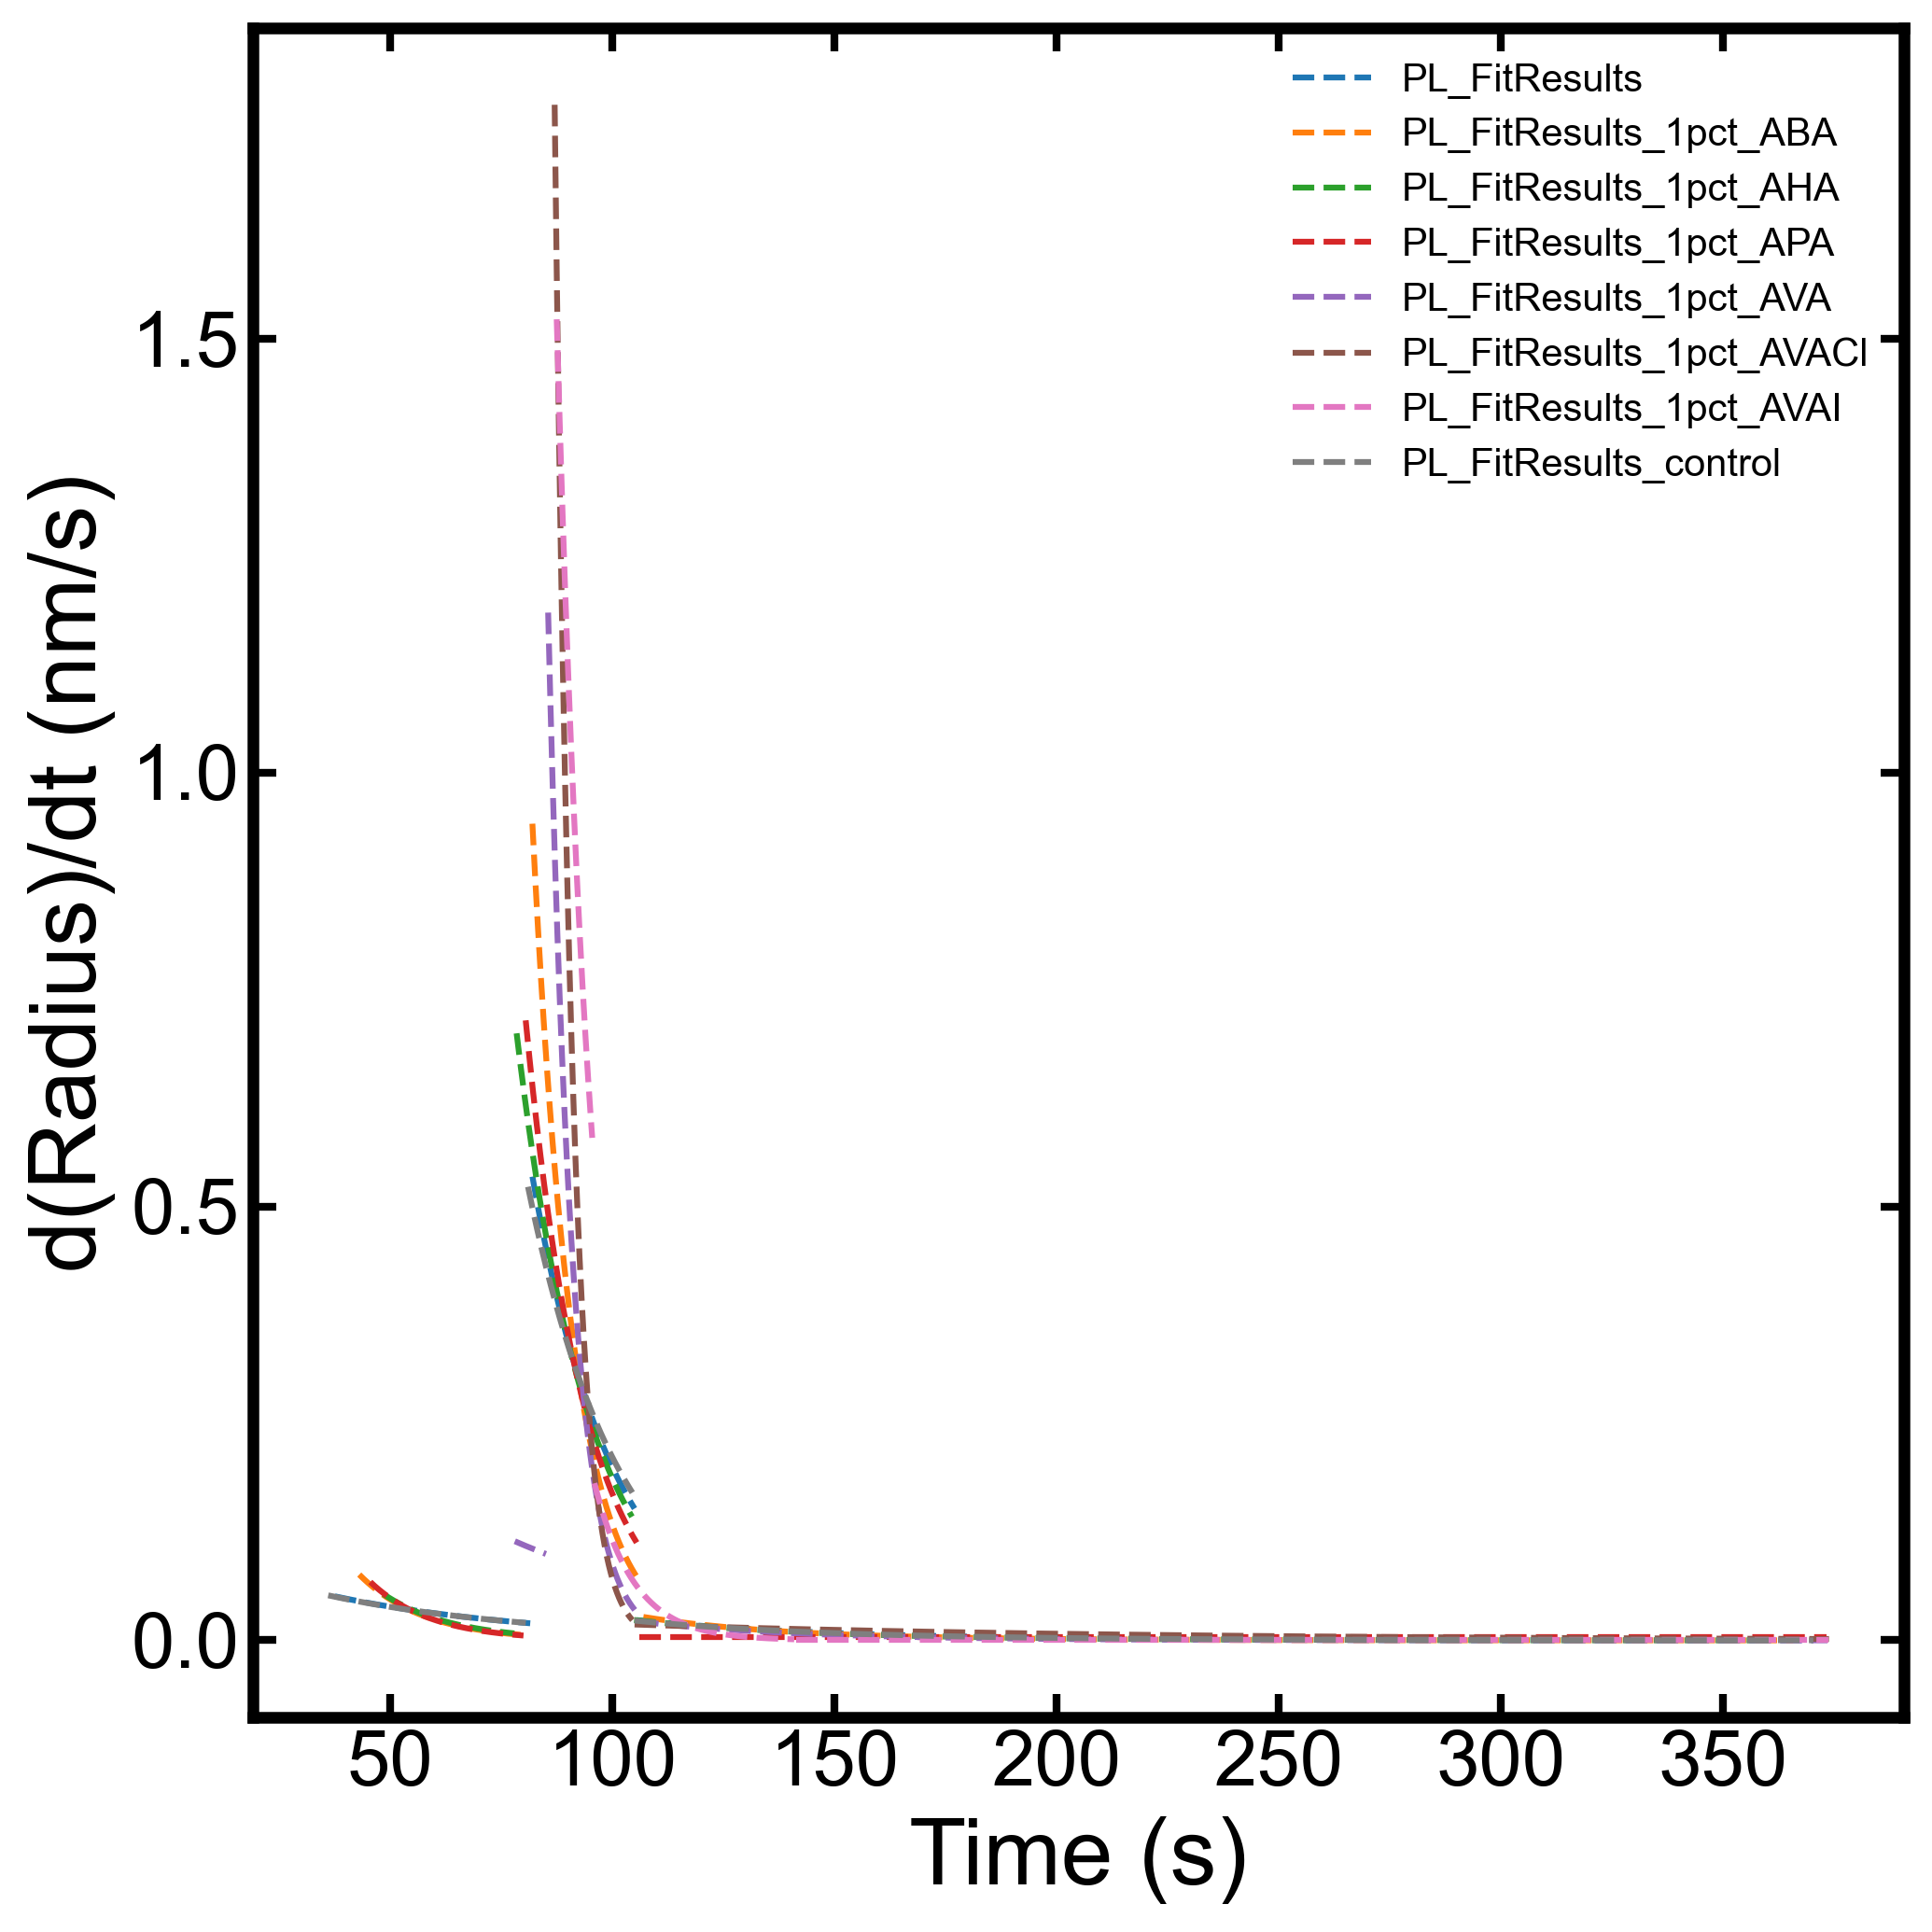

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_ALL_DATASETS_growth_rate.png


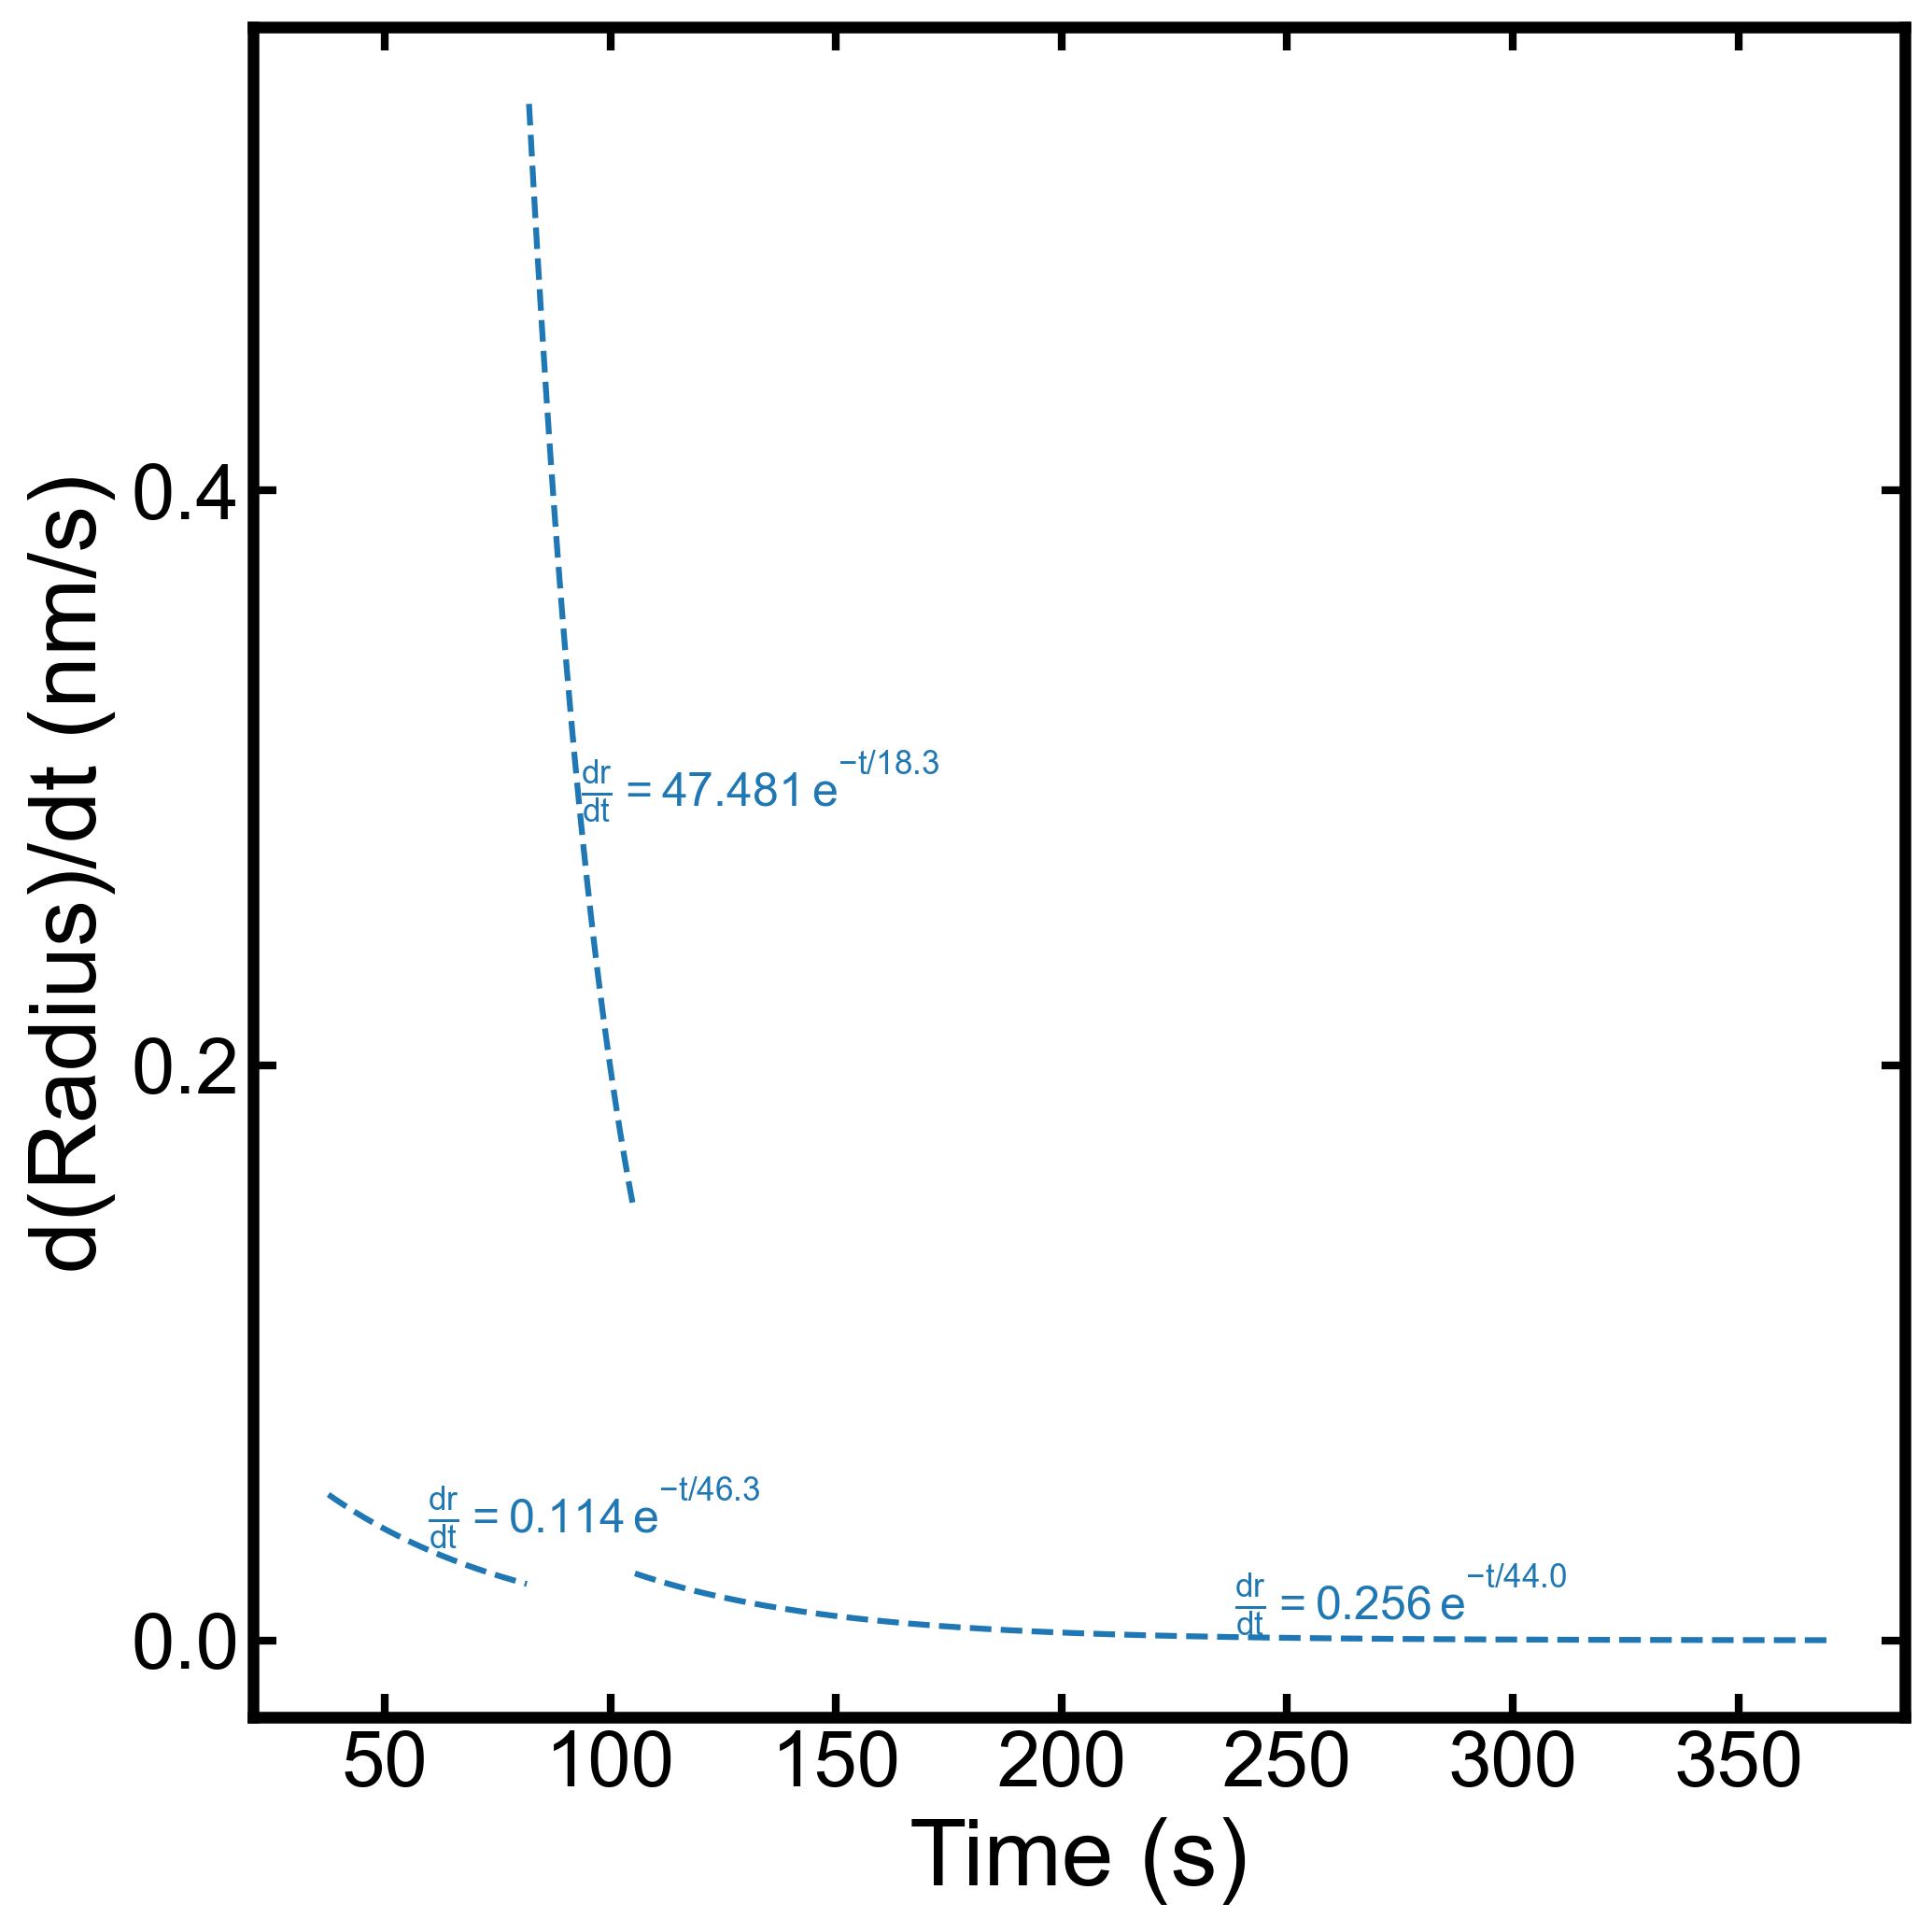

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_PL_FitResults_growth_rate.png


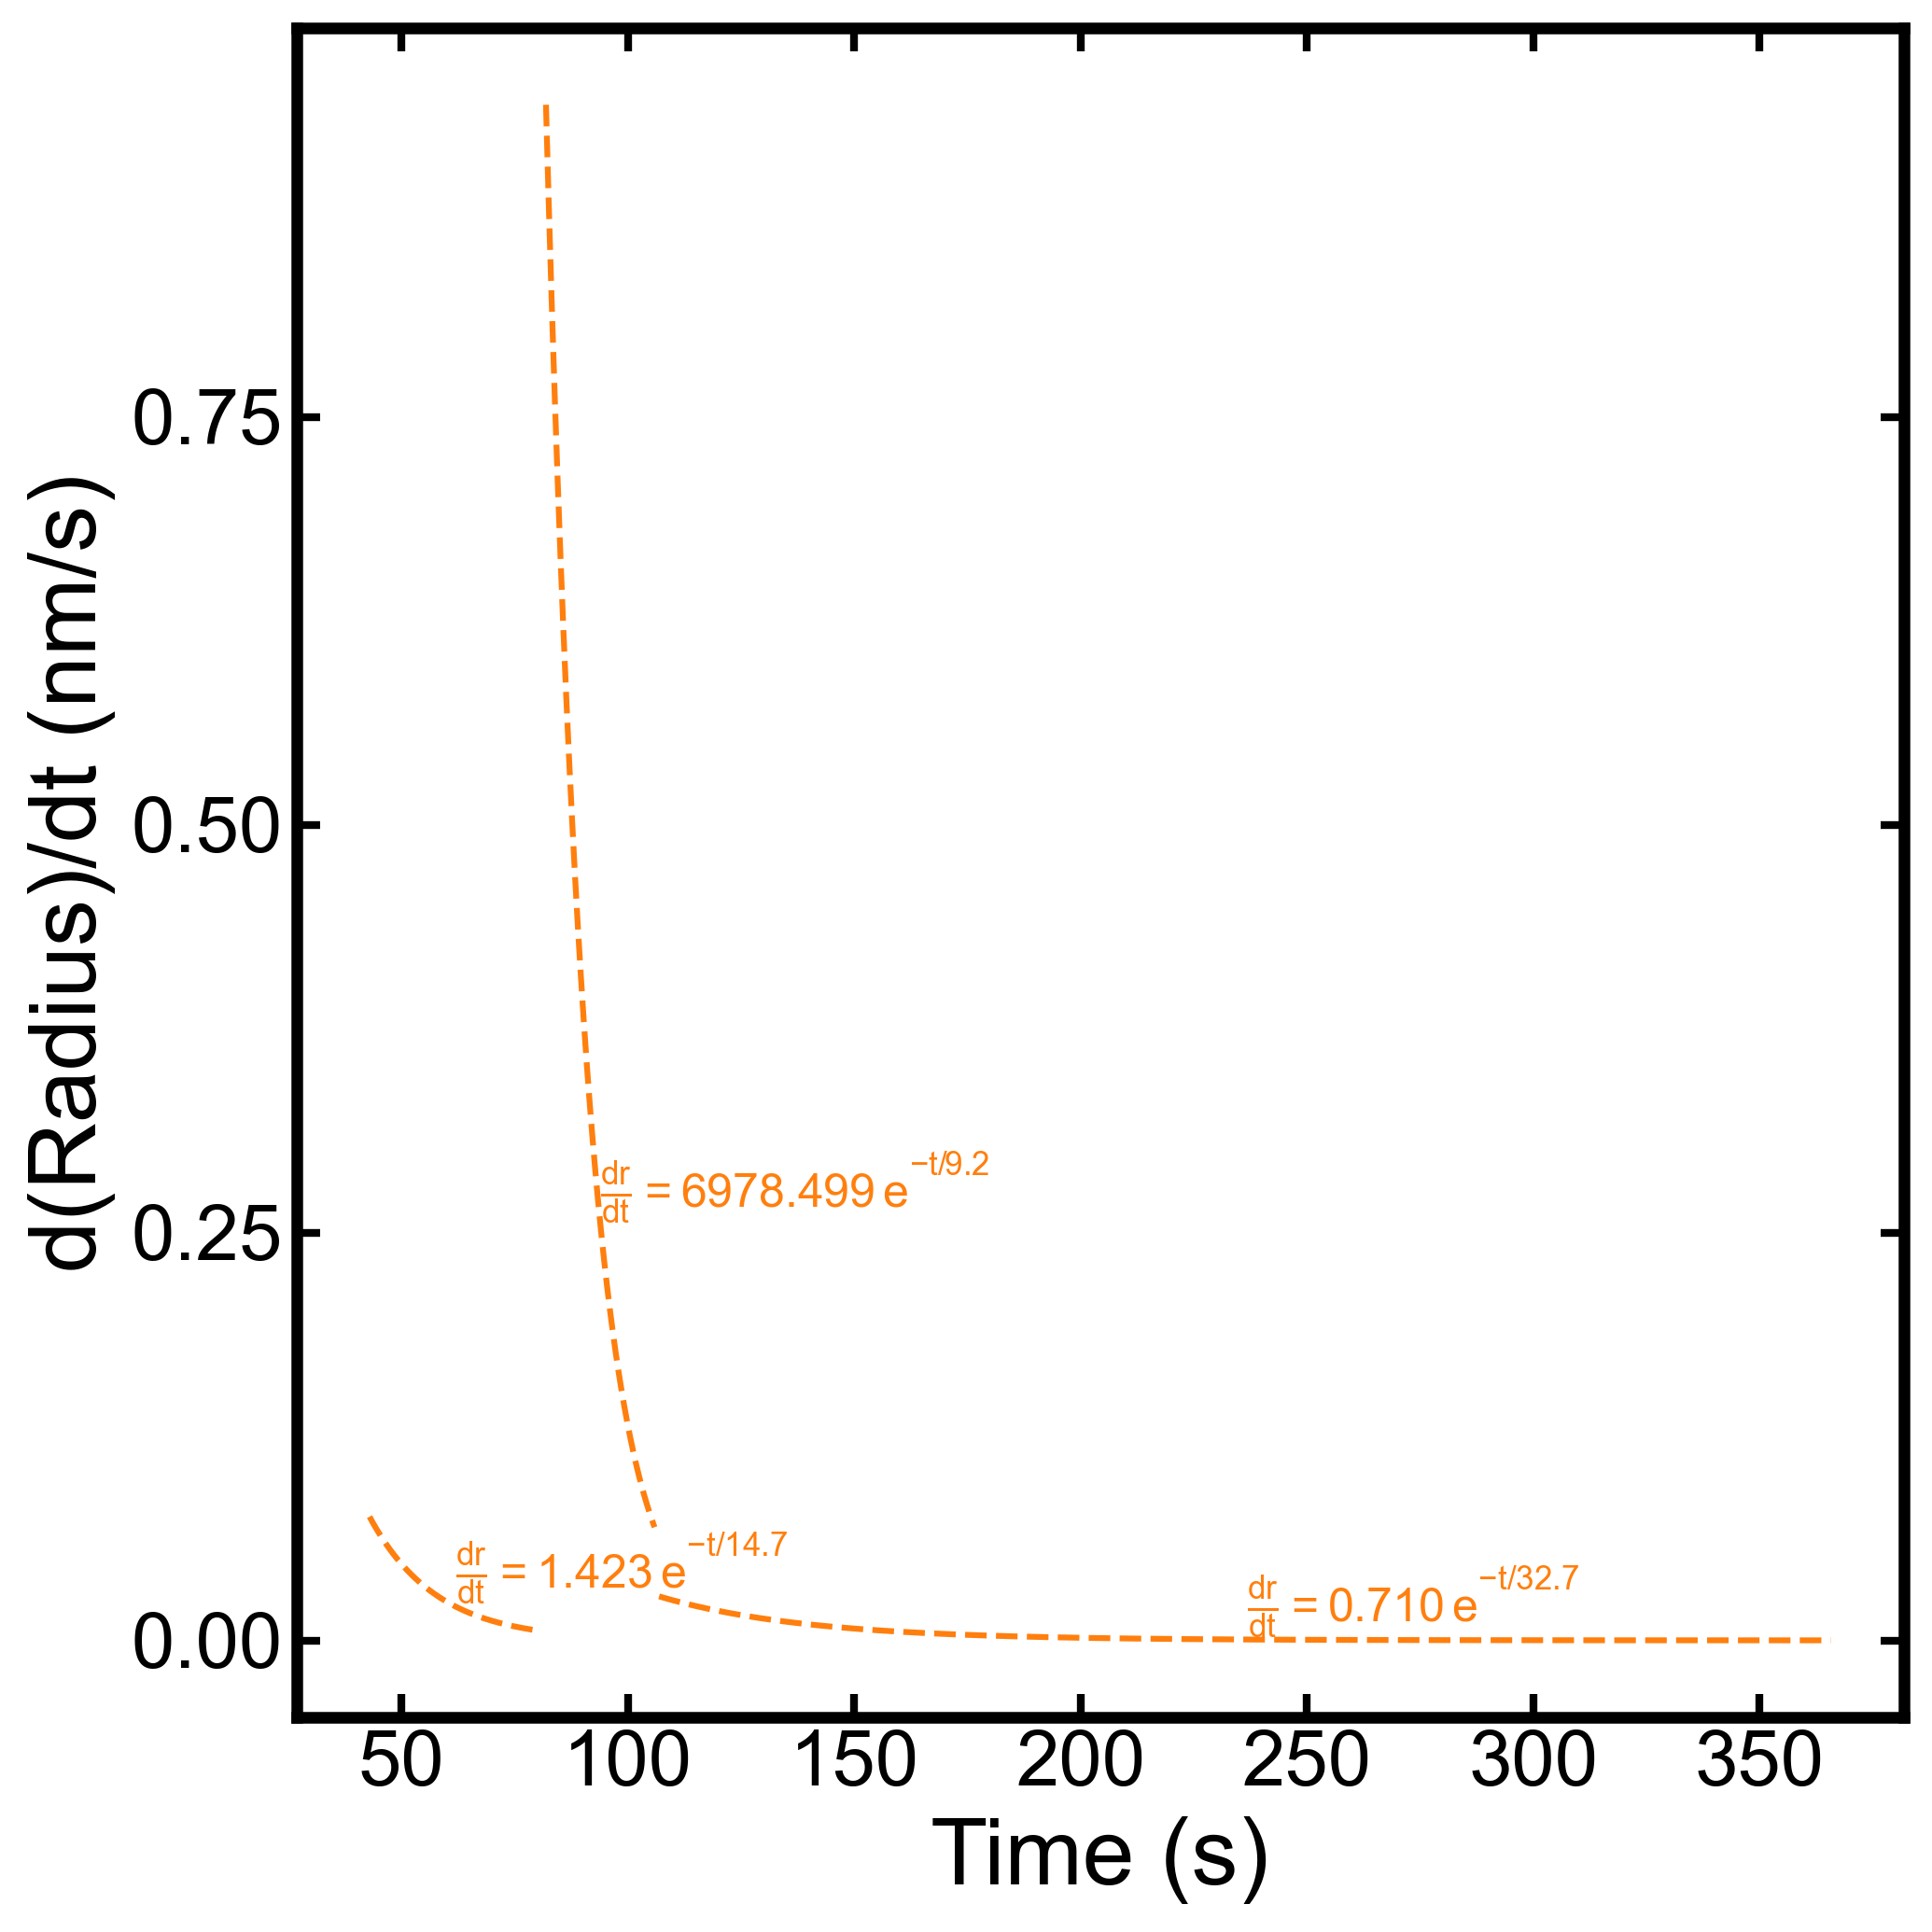

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_PL_FitResults_1pct_ABA_growth_rate.png


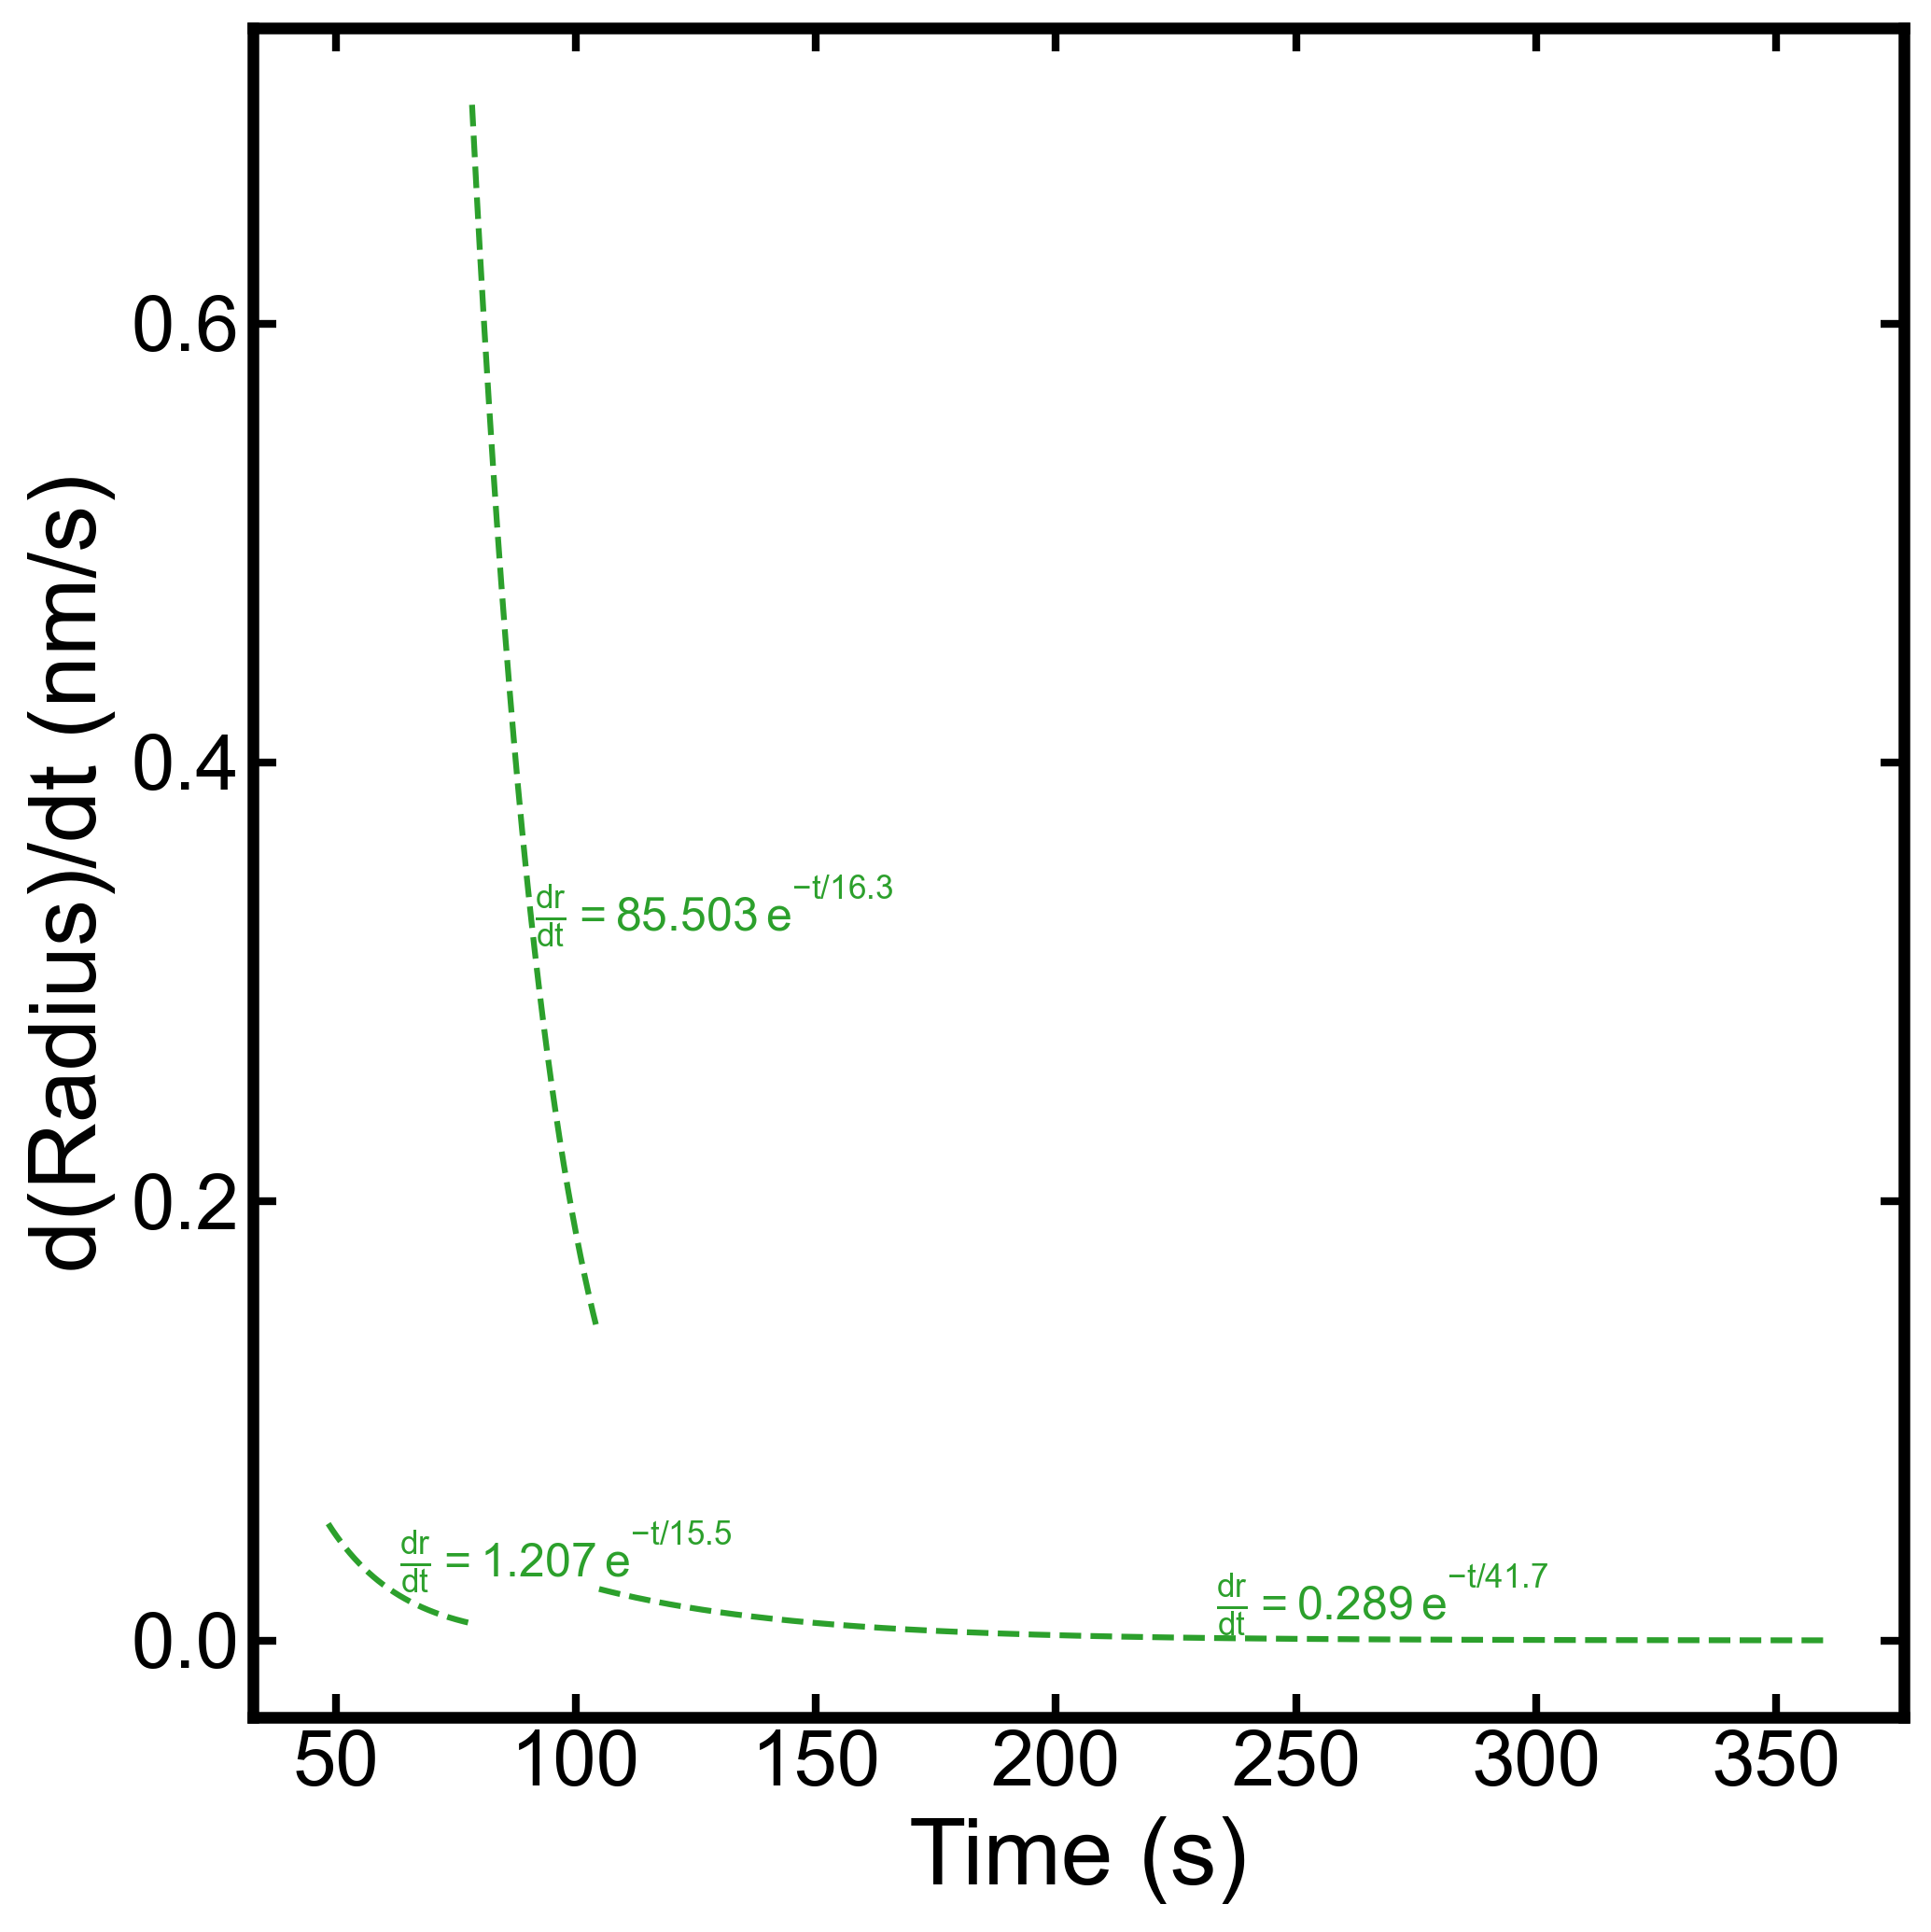

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_PL_FitResults_1pct_AHA_growth_rate.png


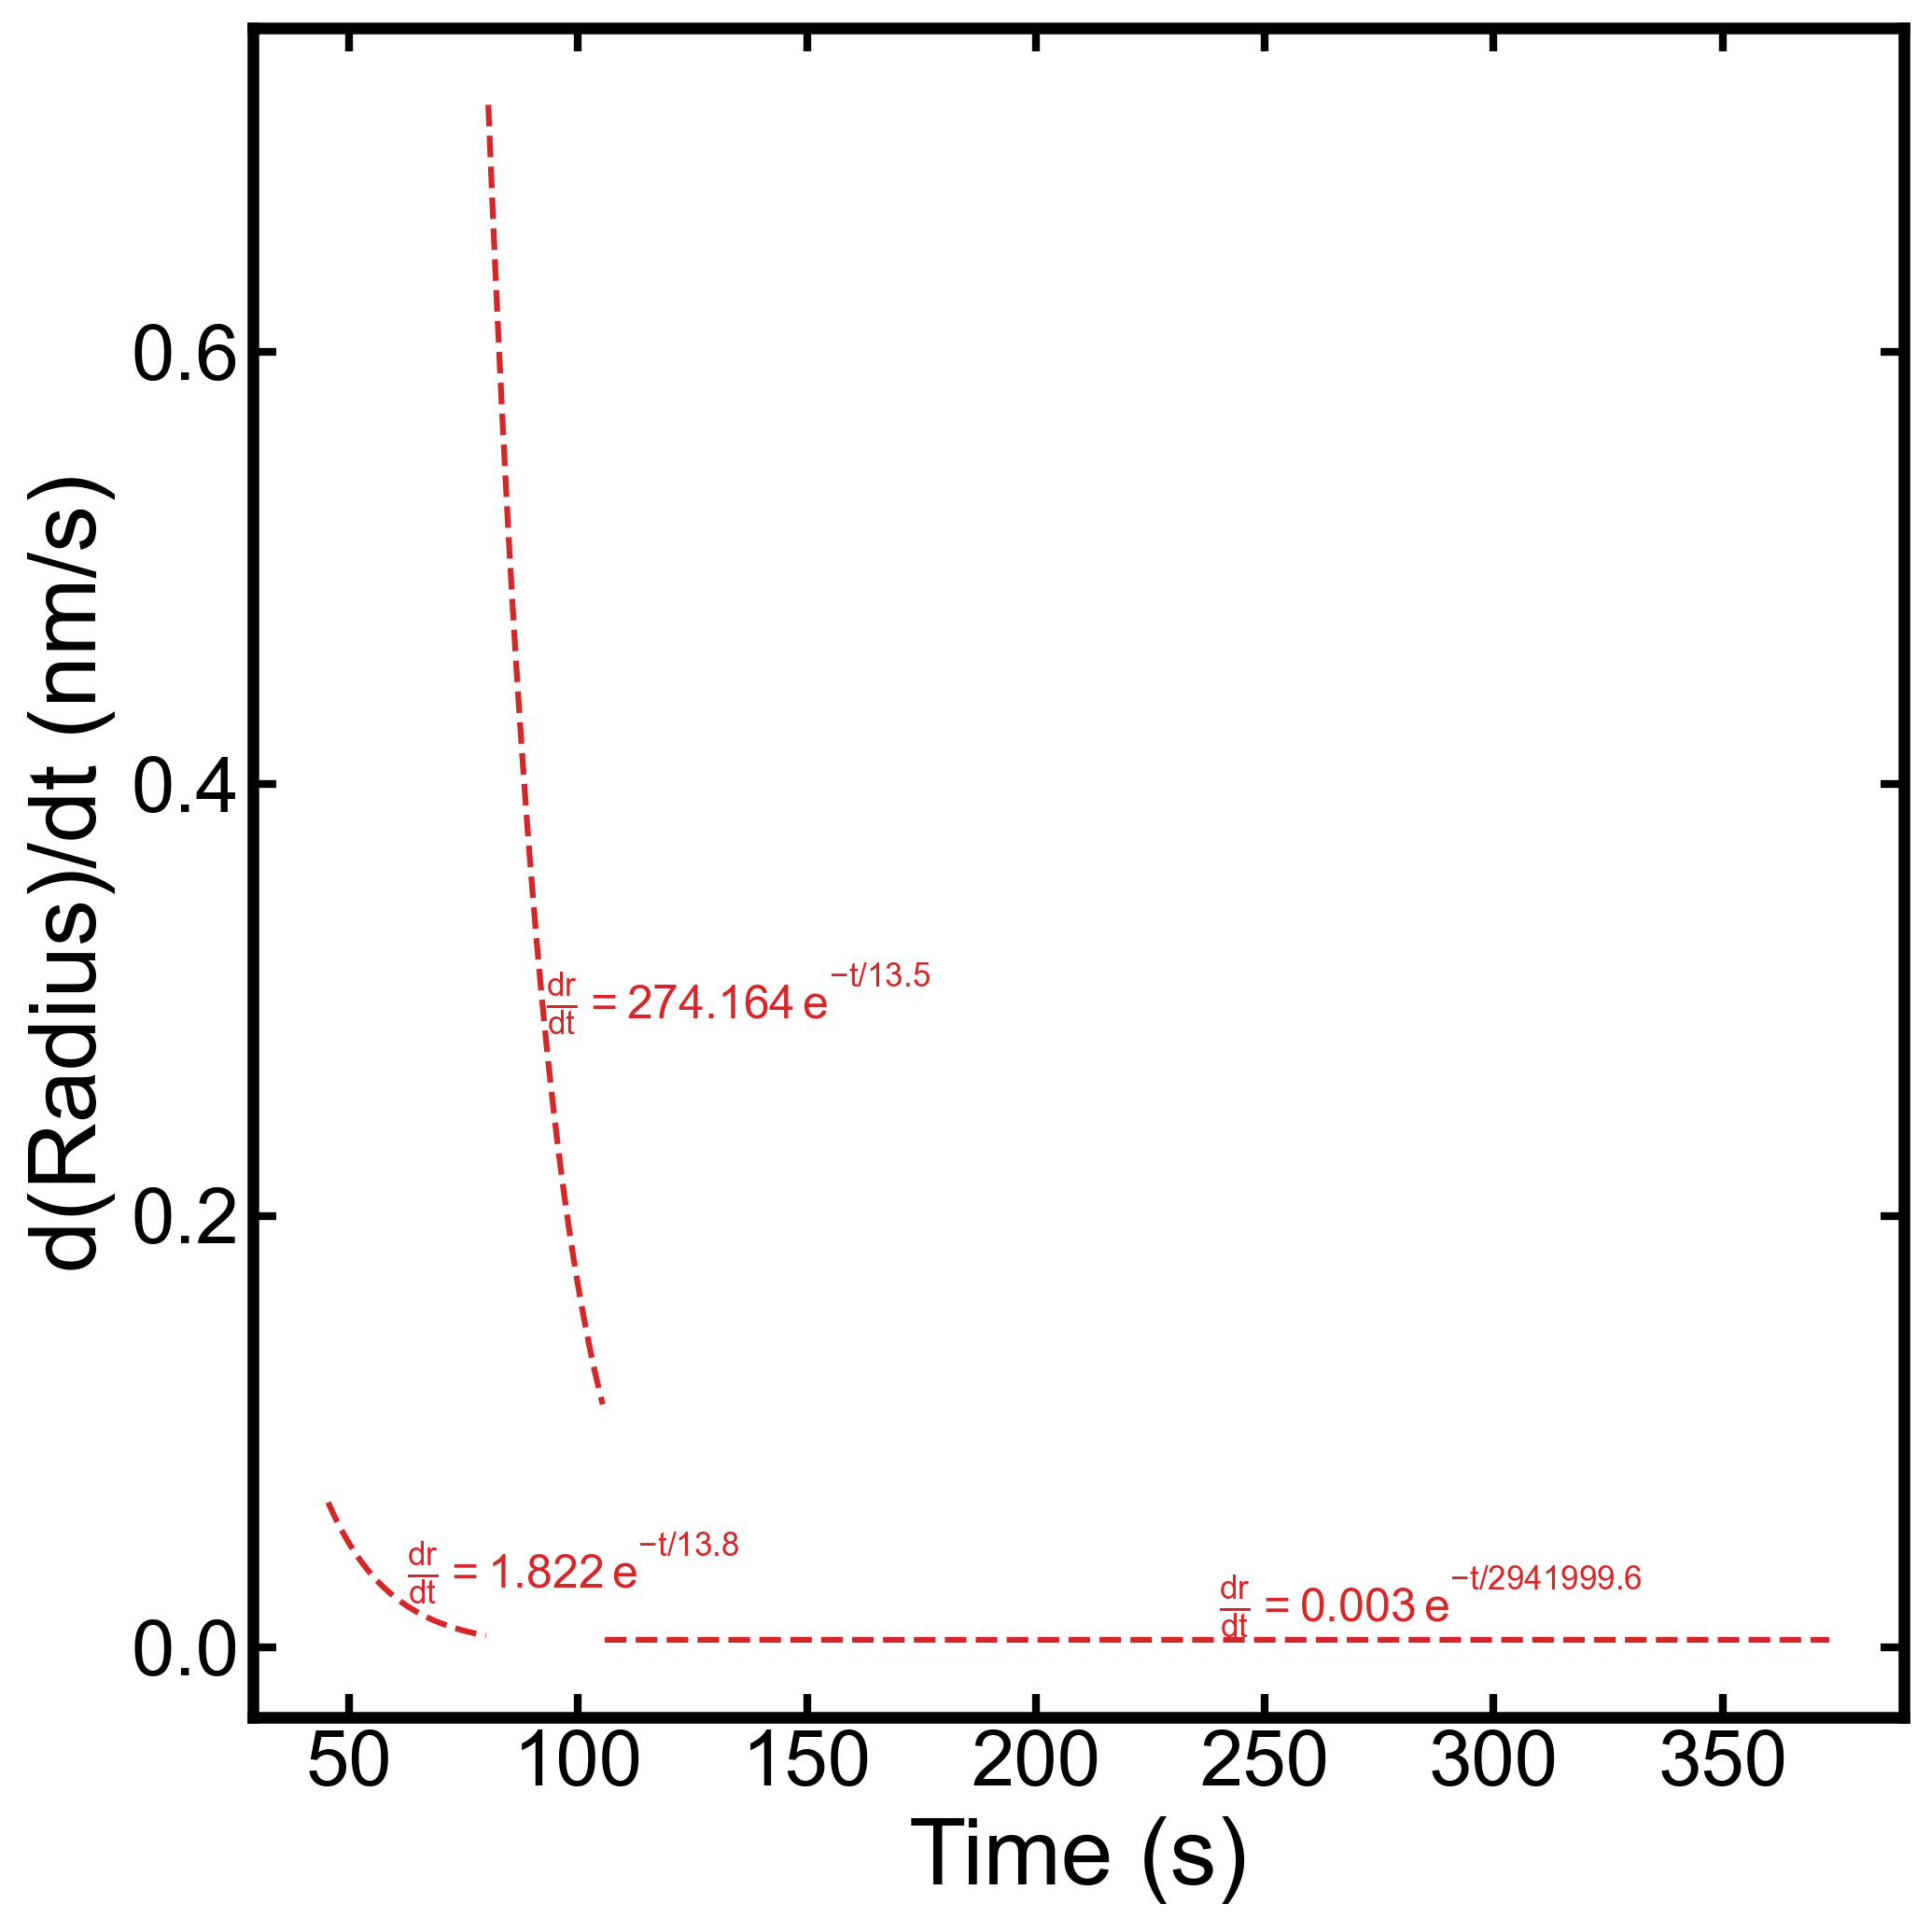

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_PL_FitResults_1pct_APA_growth_rate.png


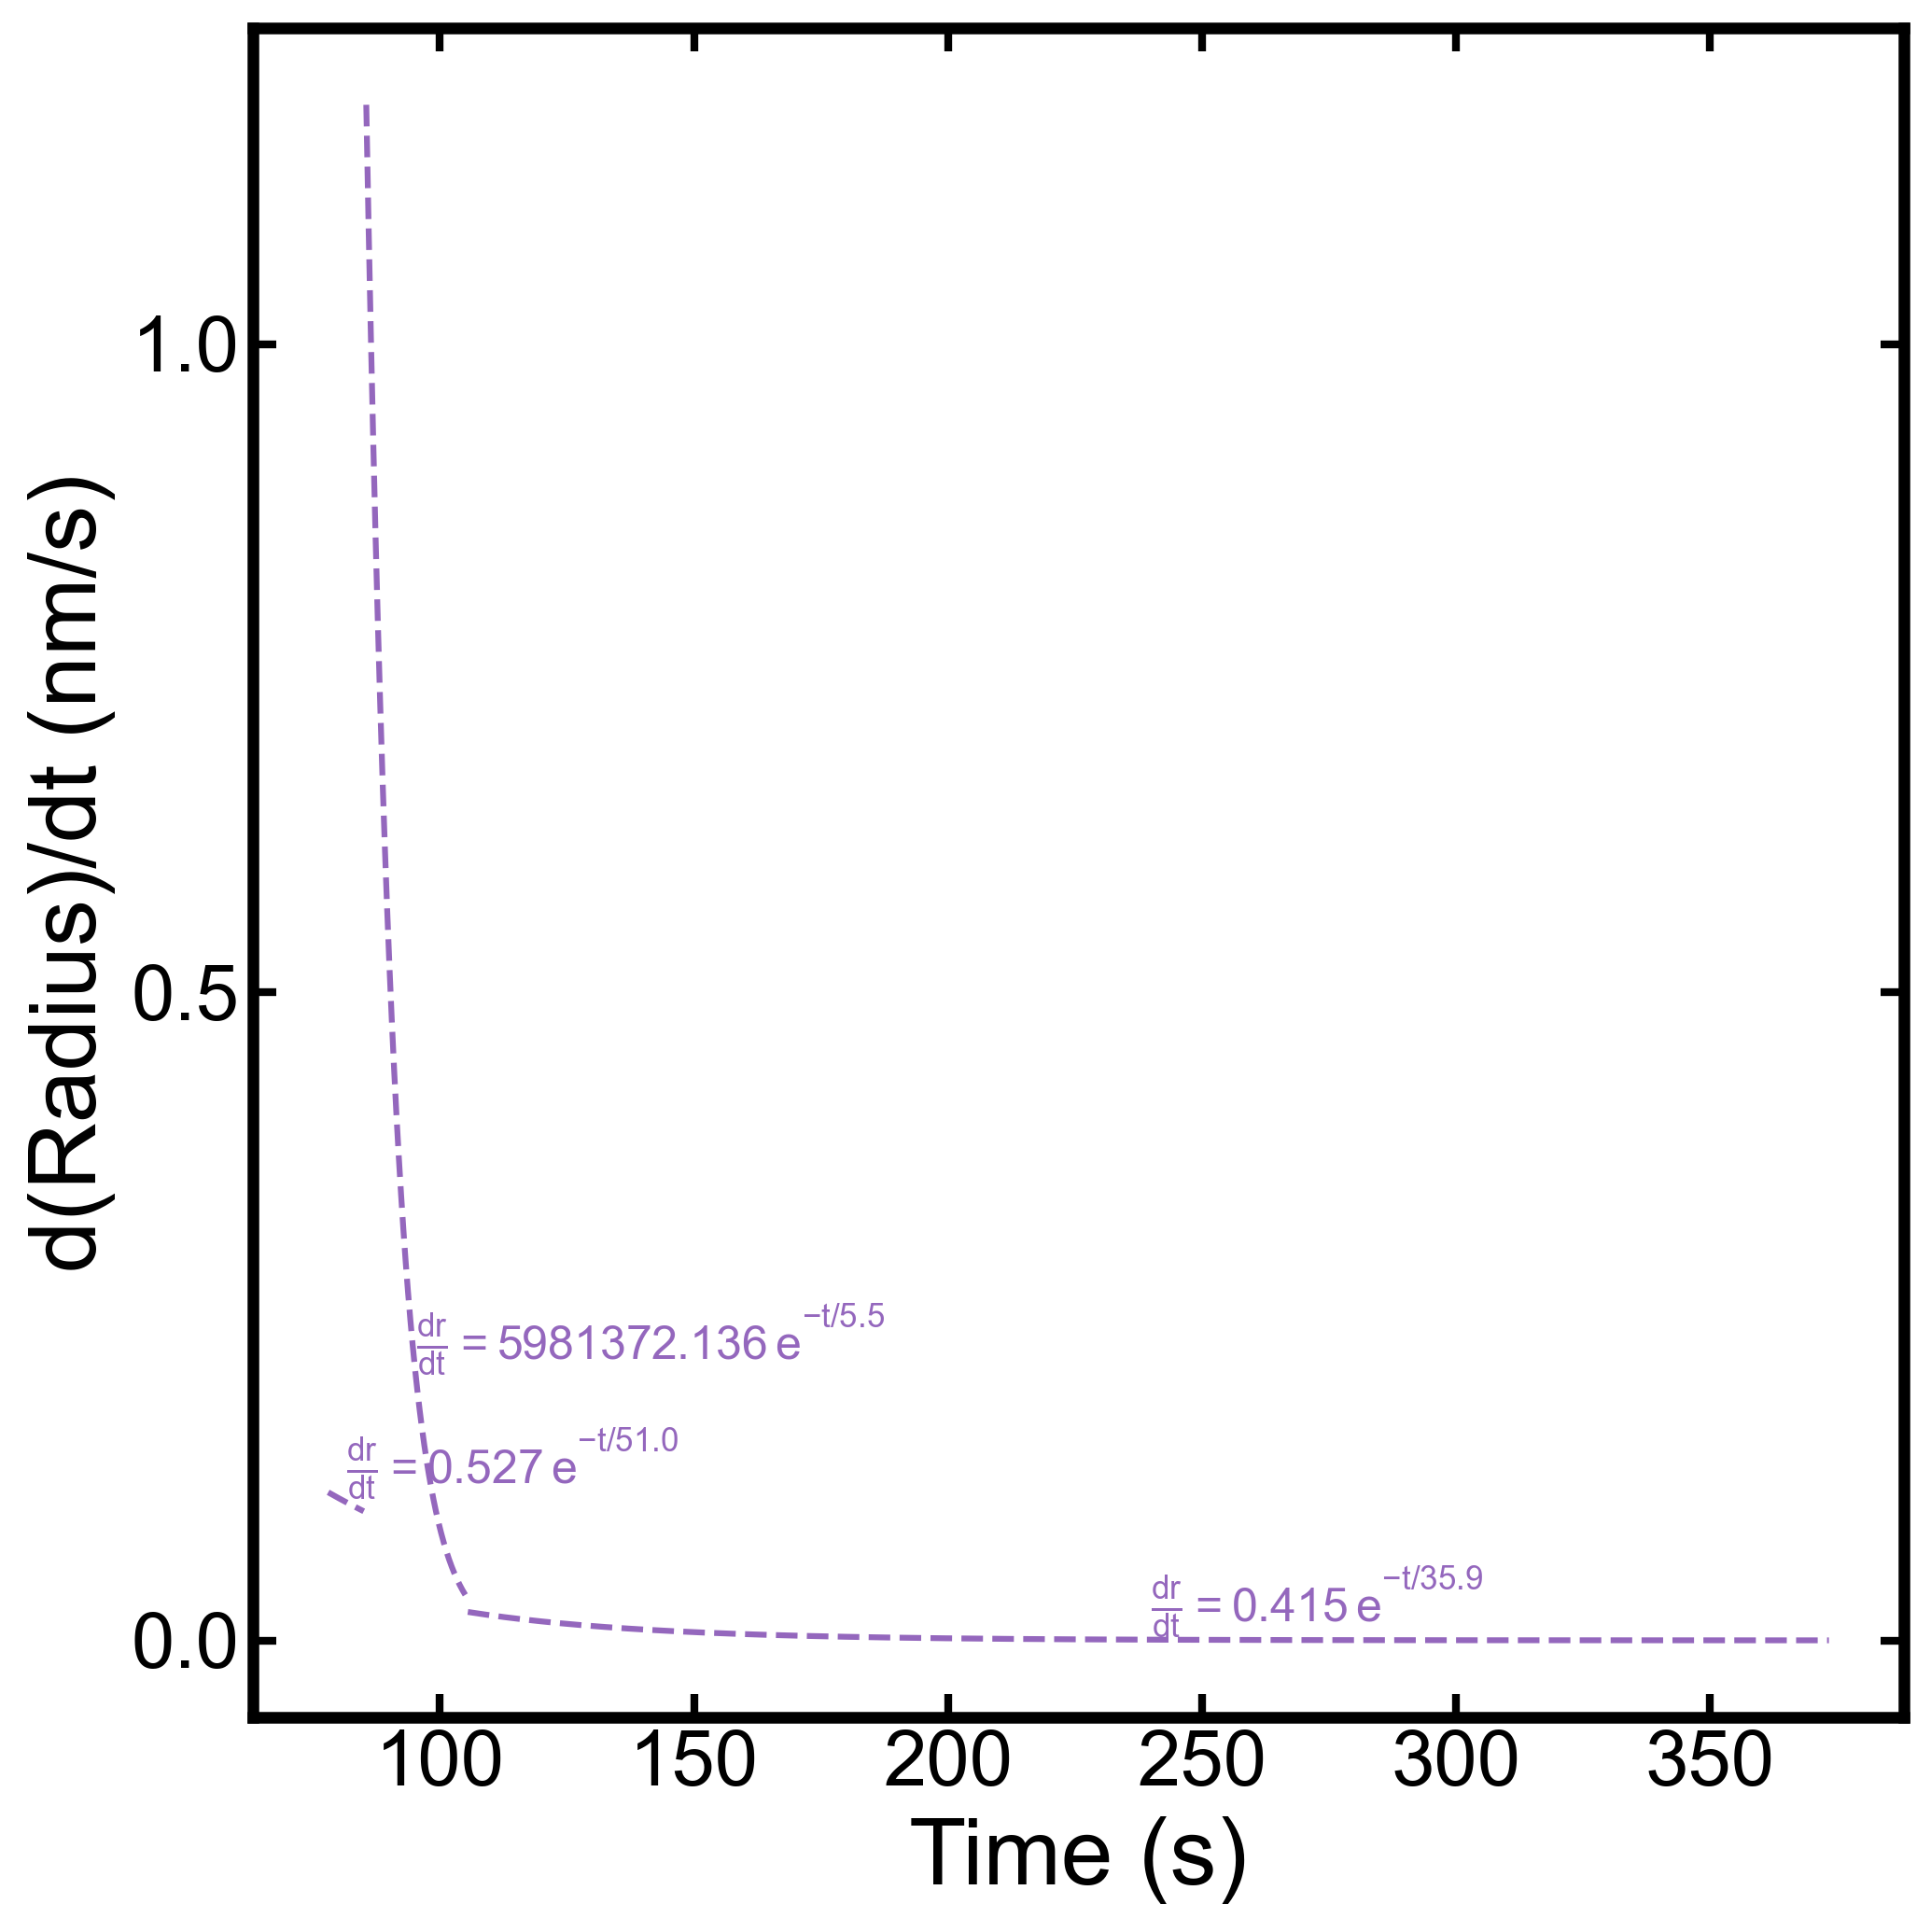

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_PL_FitResults_1pct_AVA_growth_rate.png


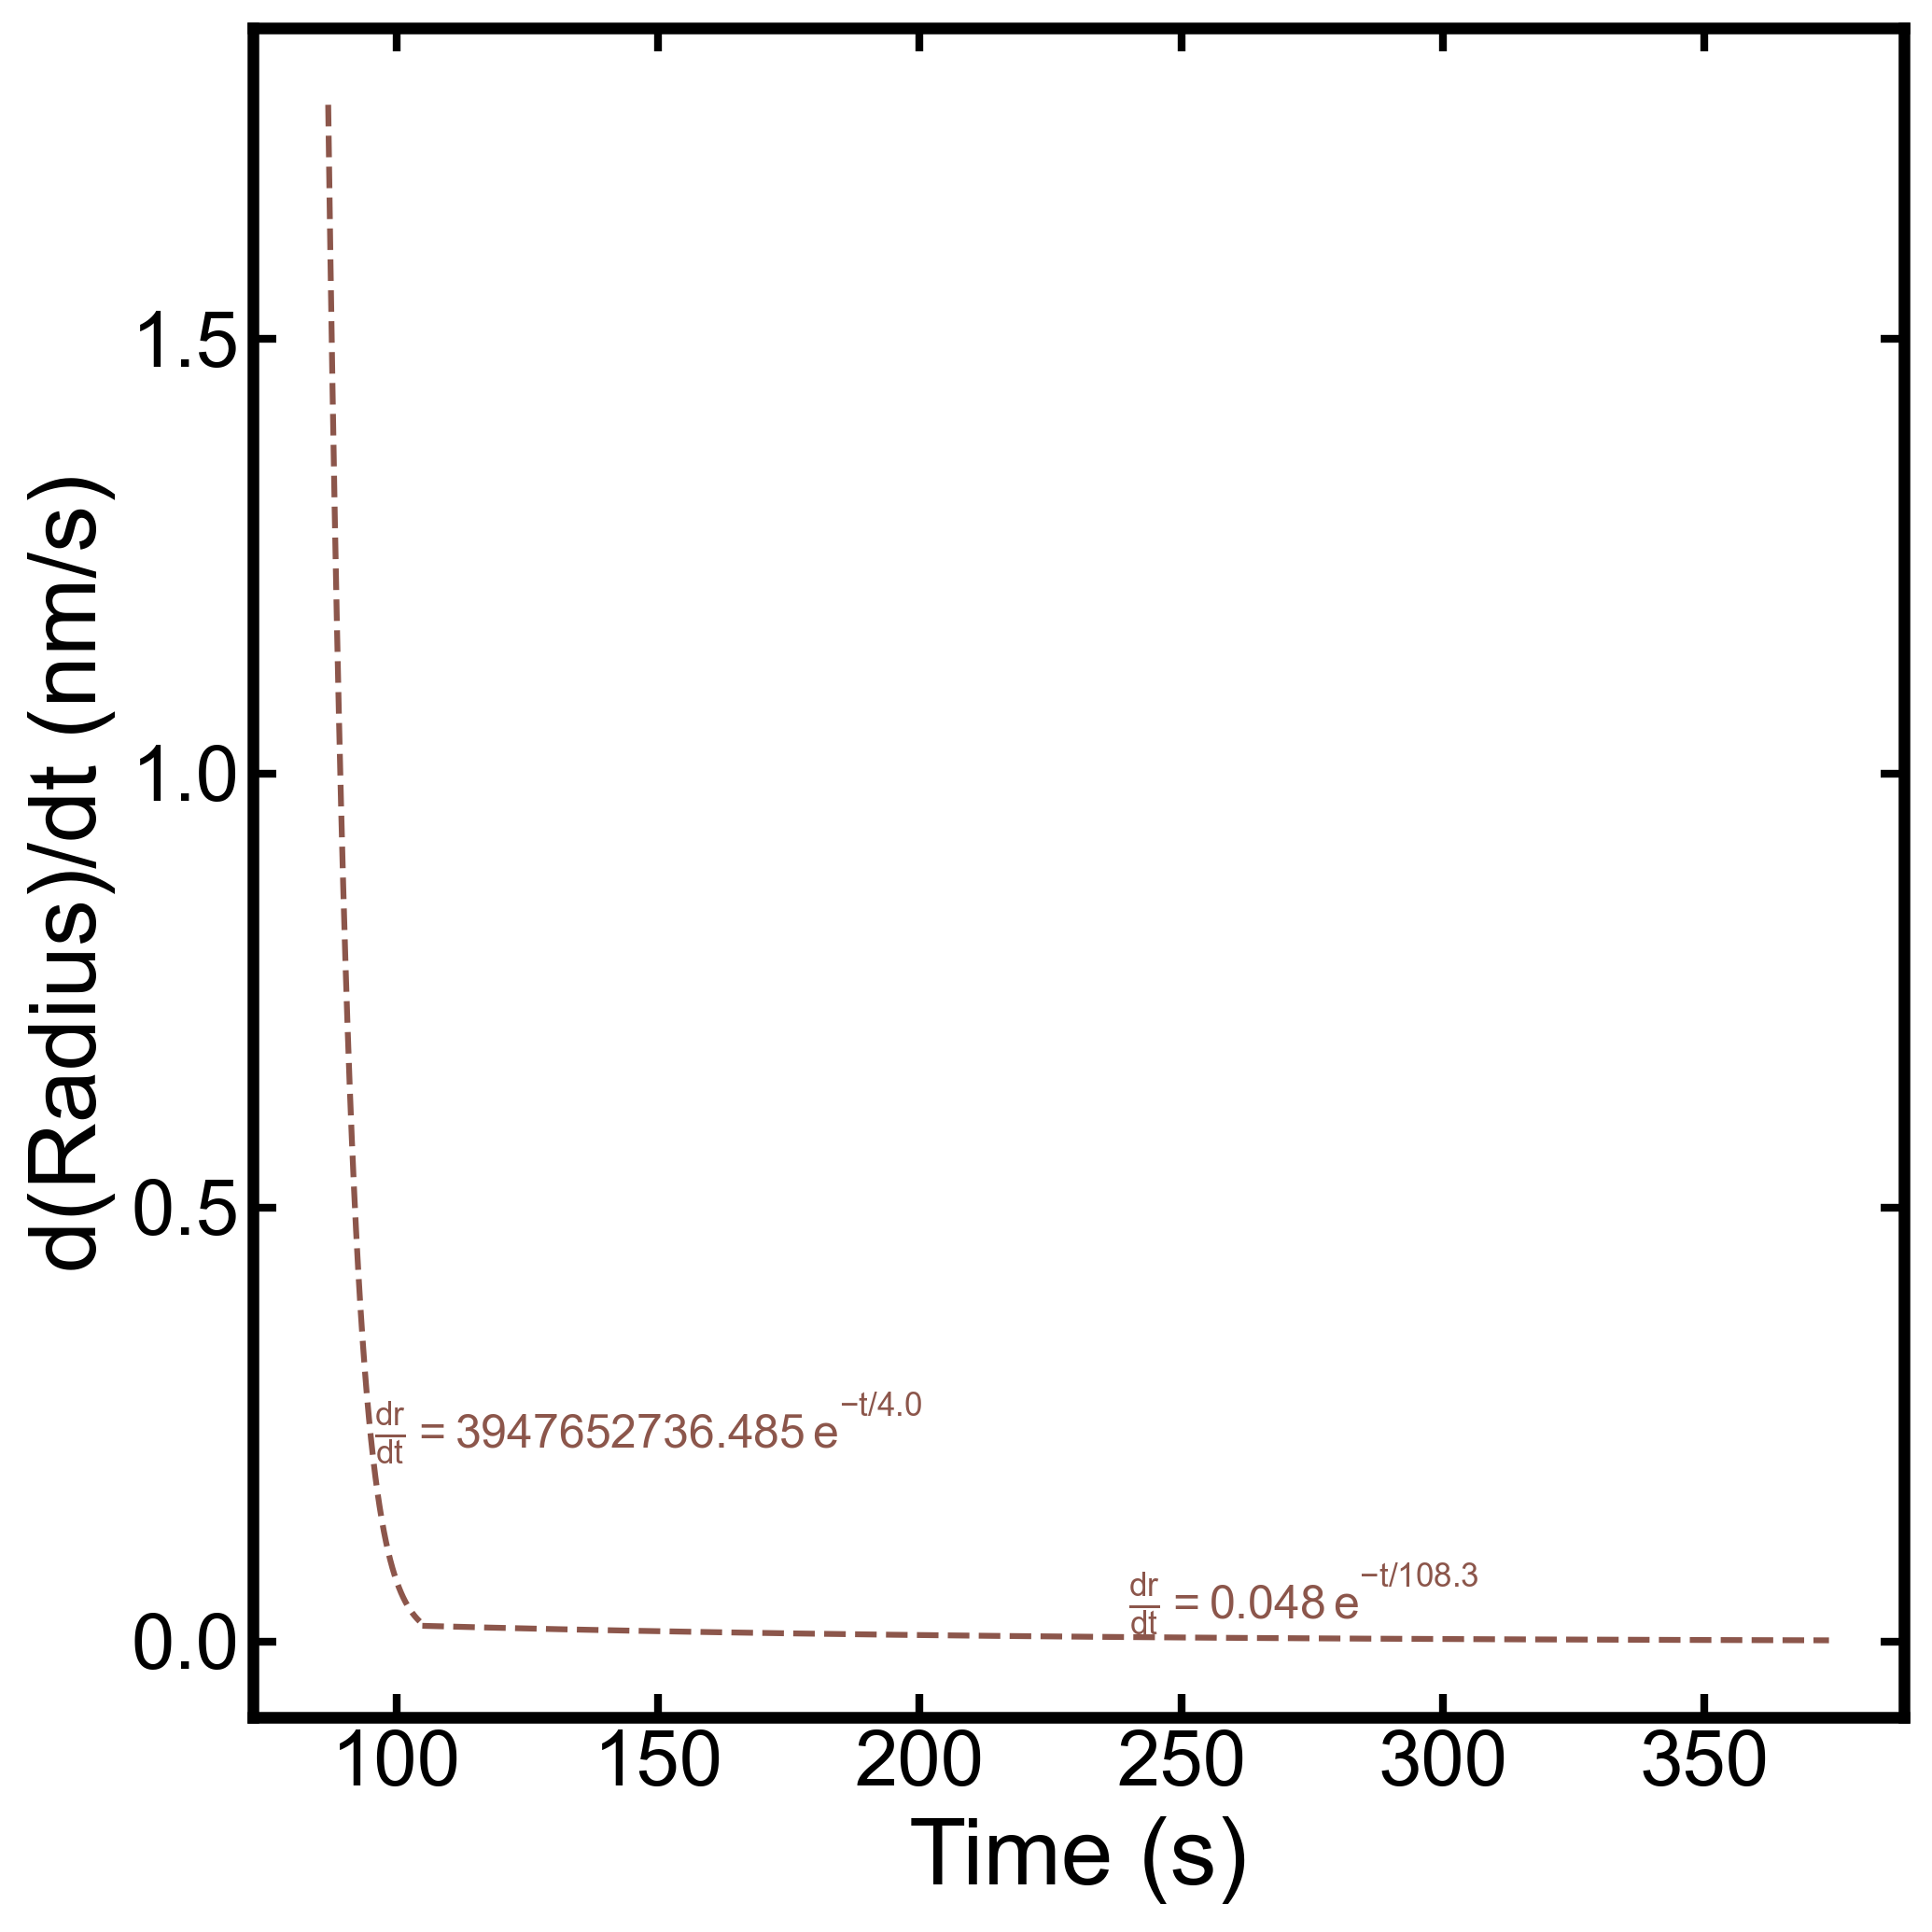

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_PL_FitResults_1pct_AVACl_growth_rate.png


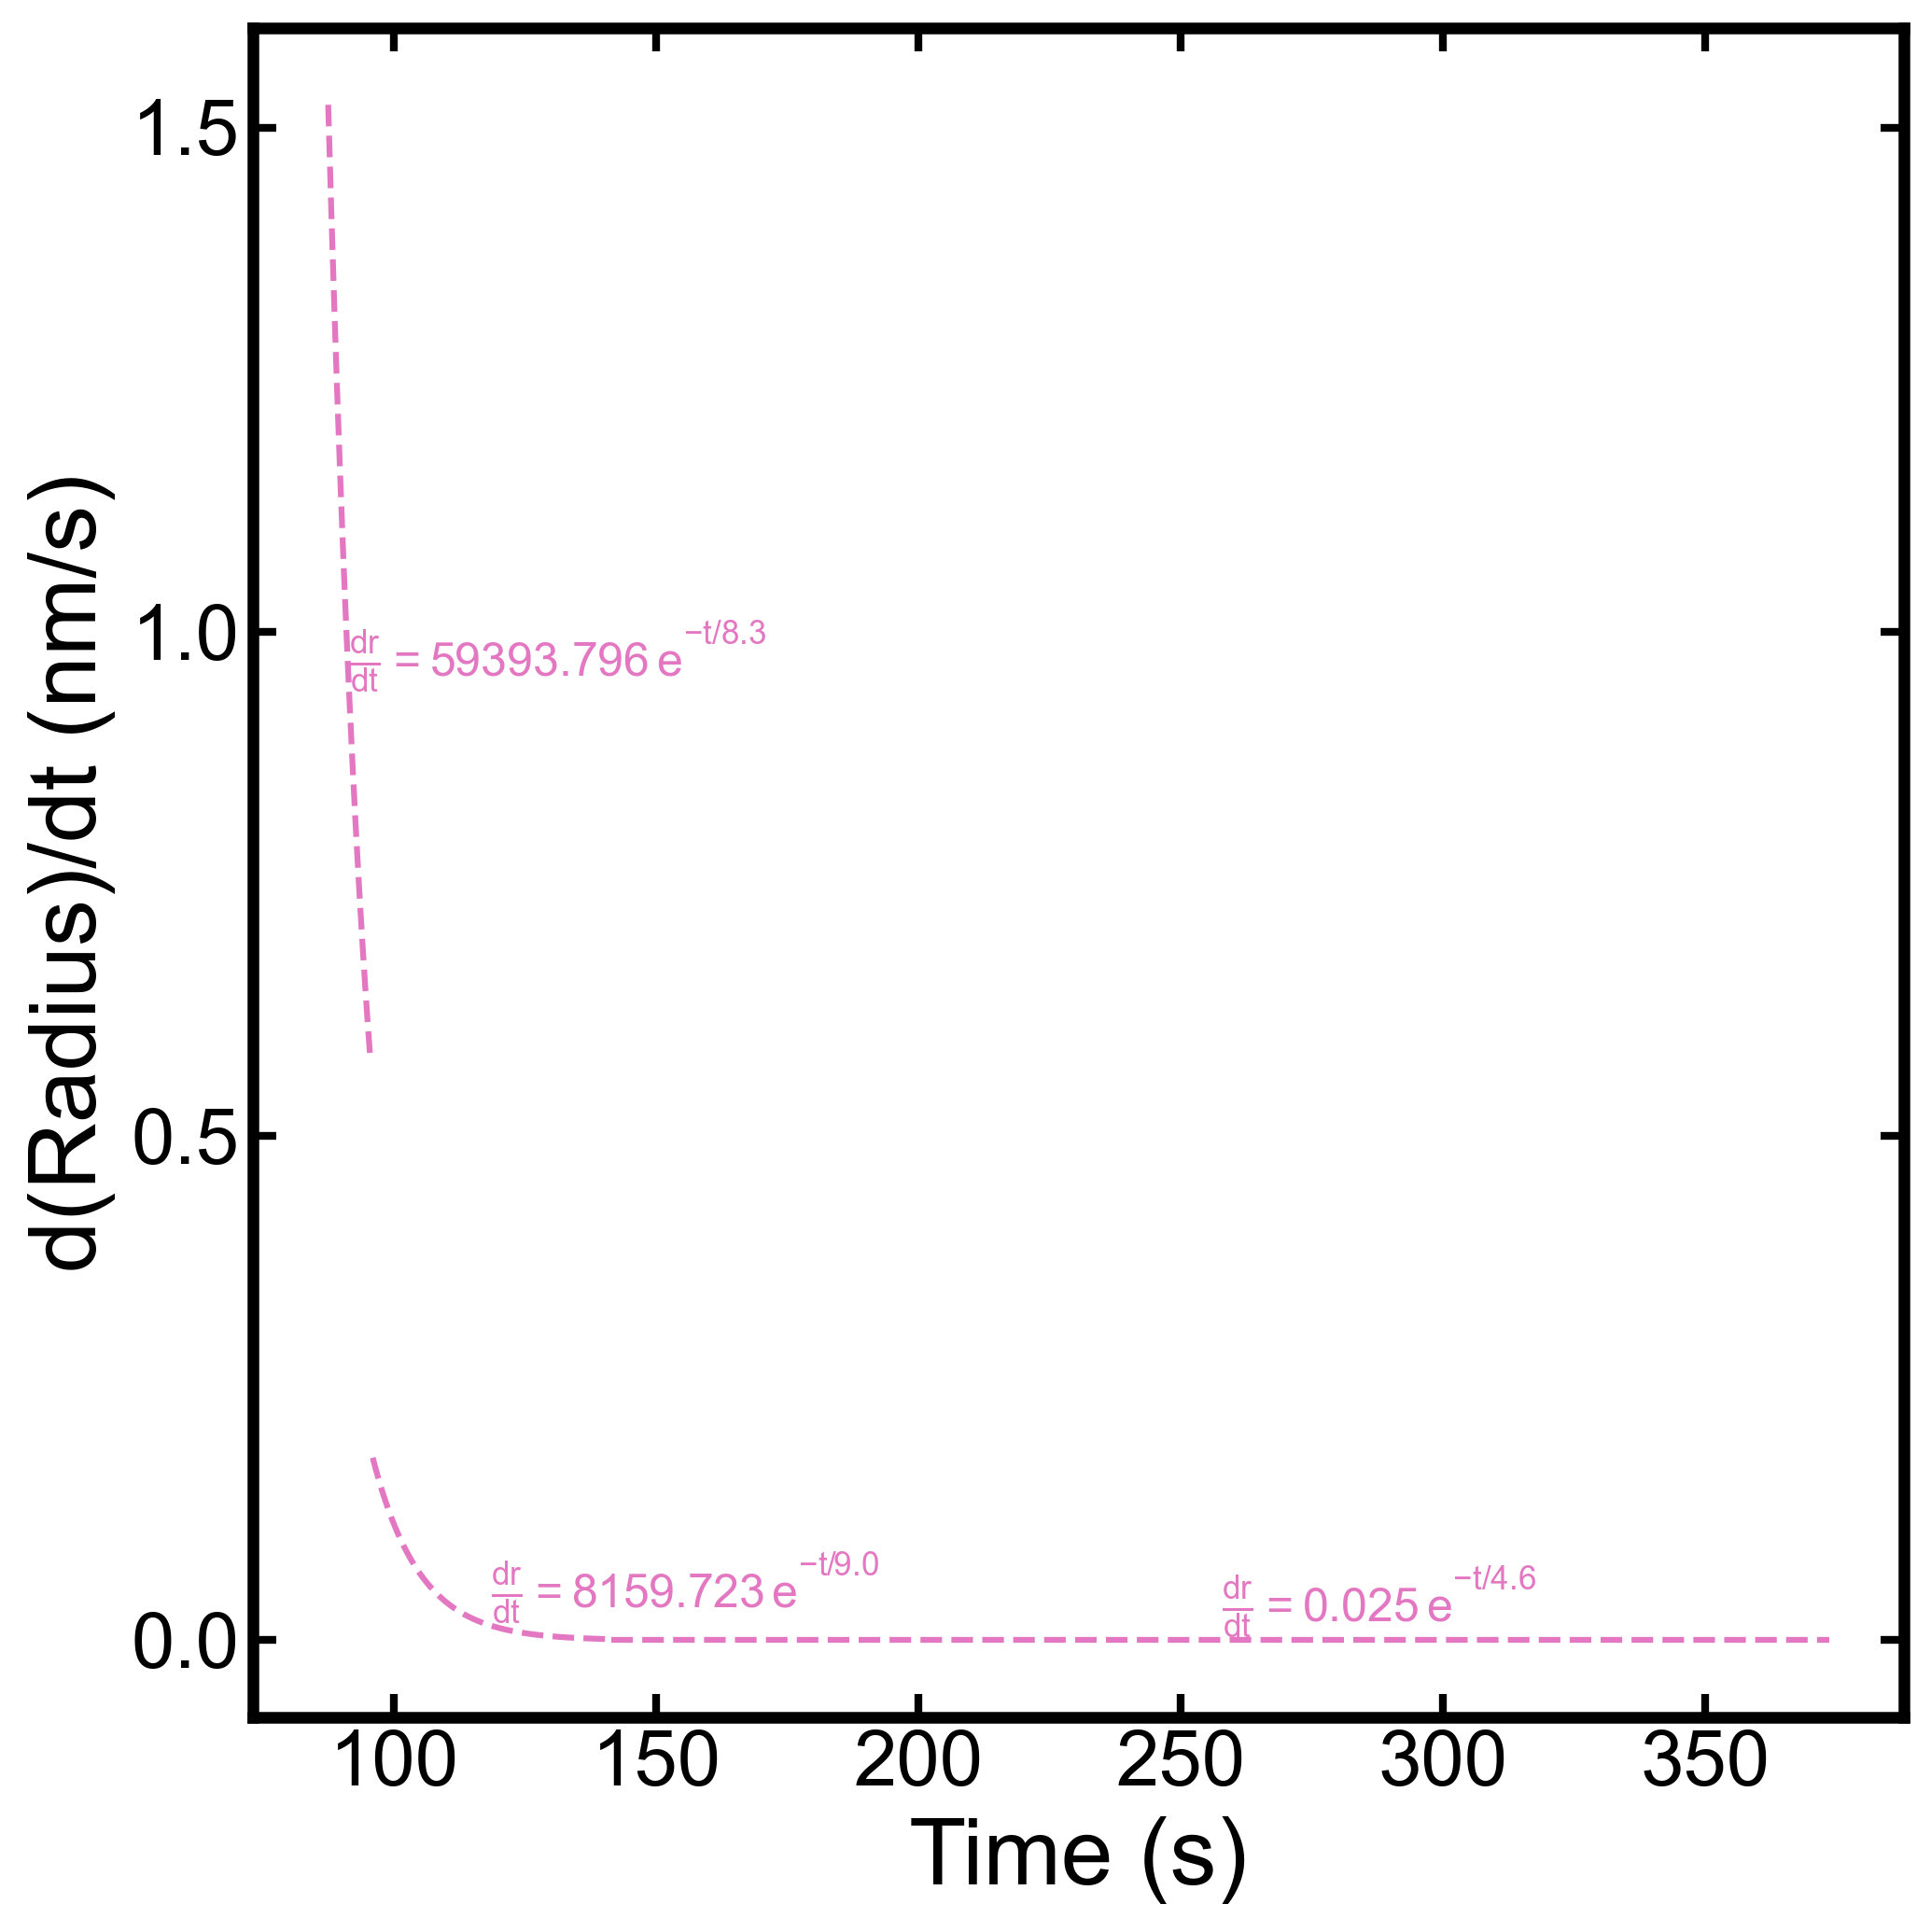

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_PL_FitResults_1pct_AVAI_growth_rate.png


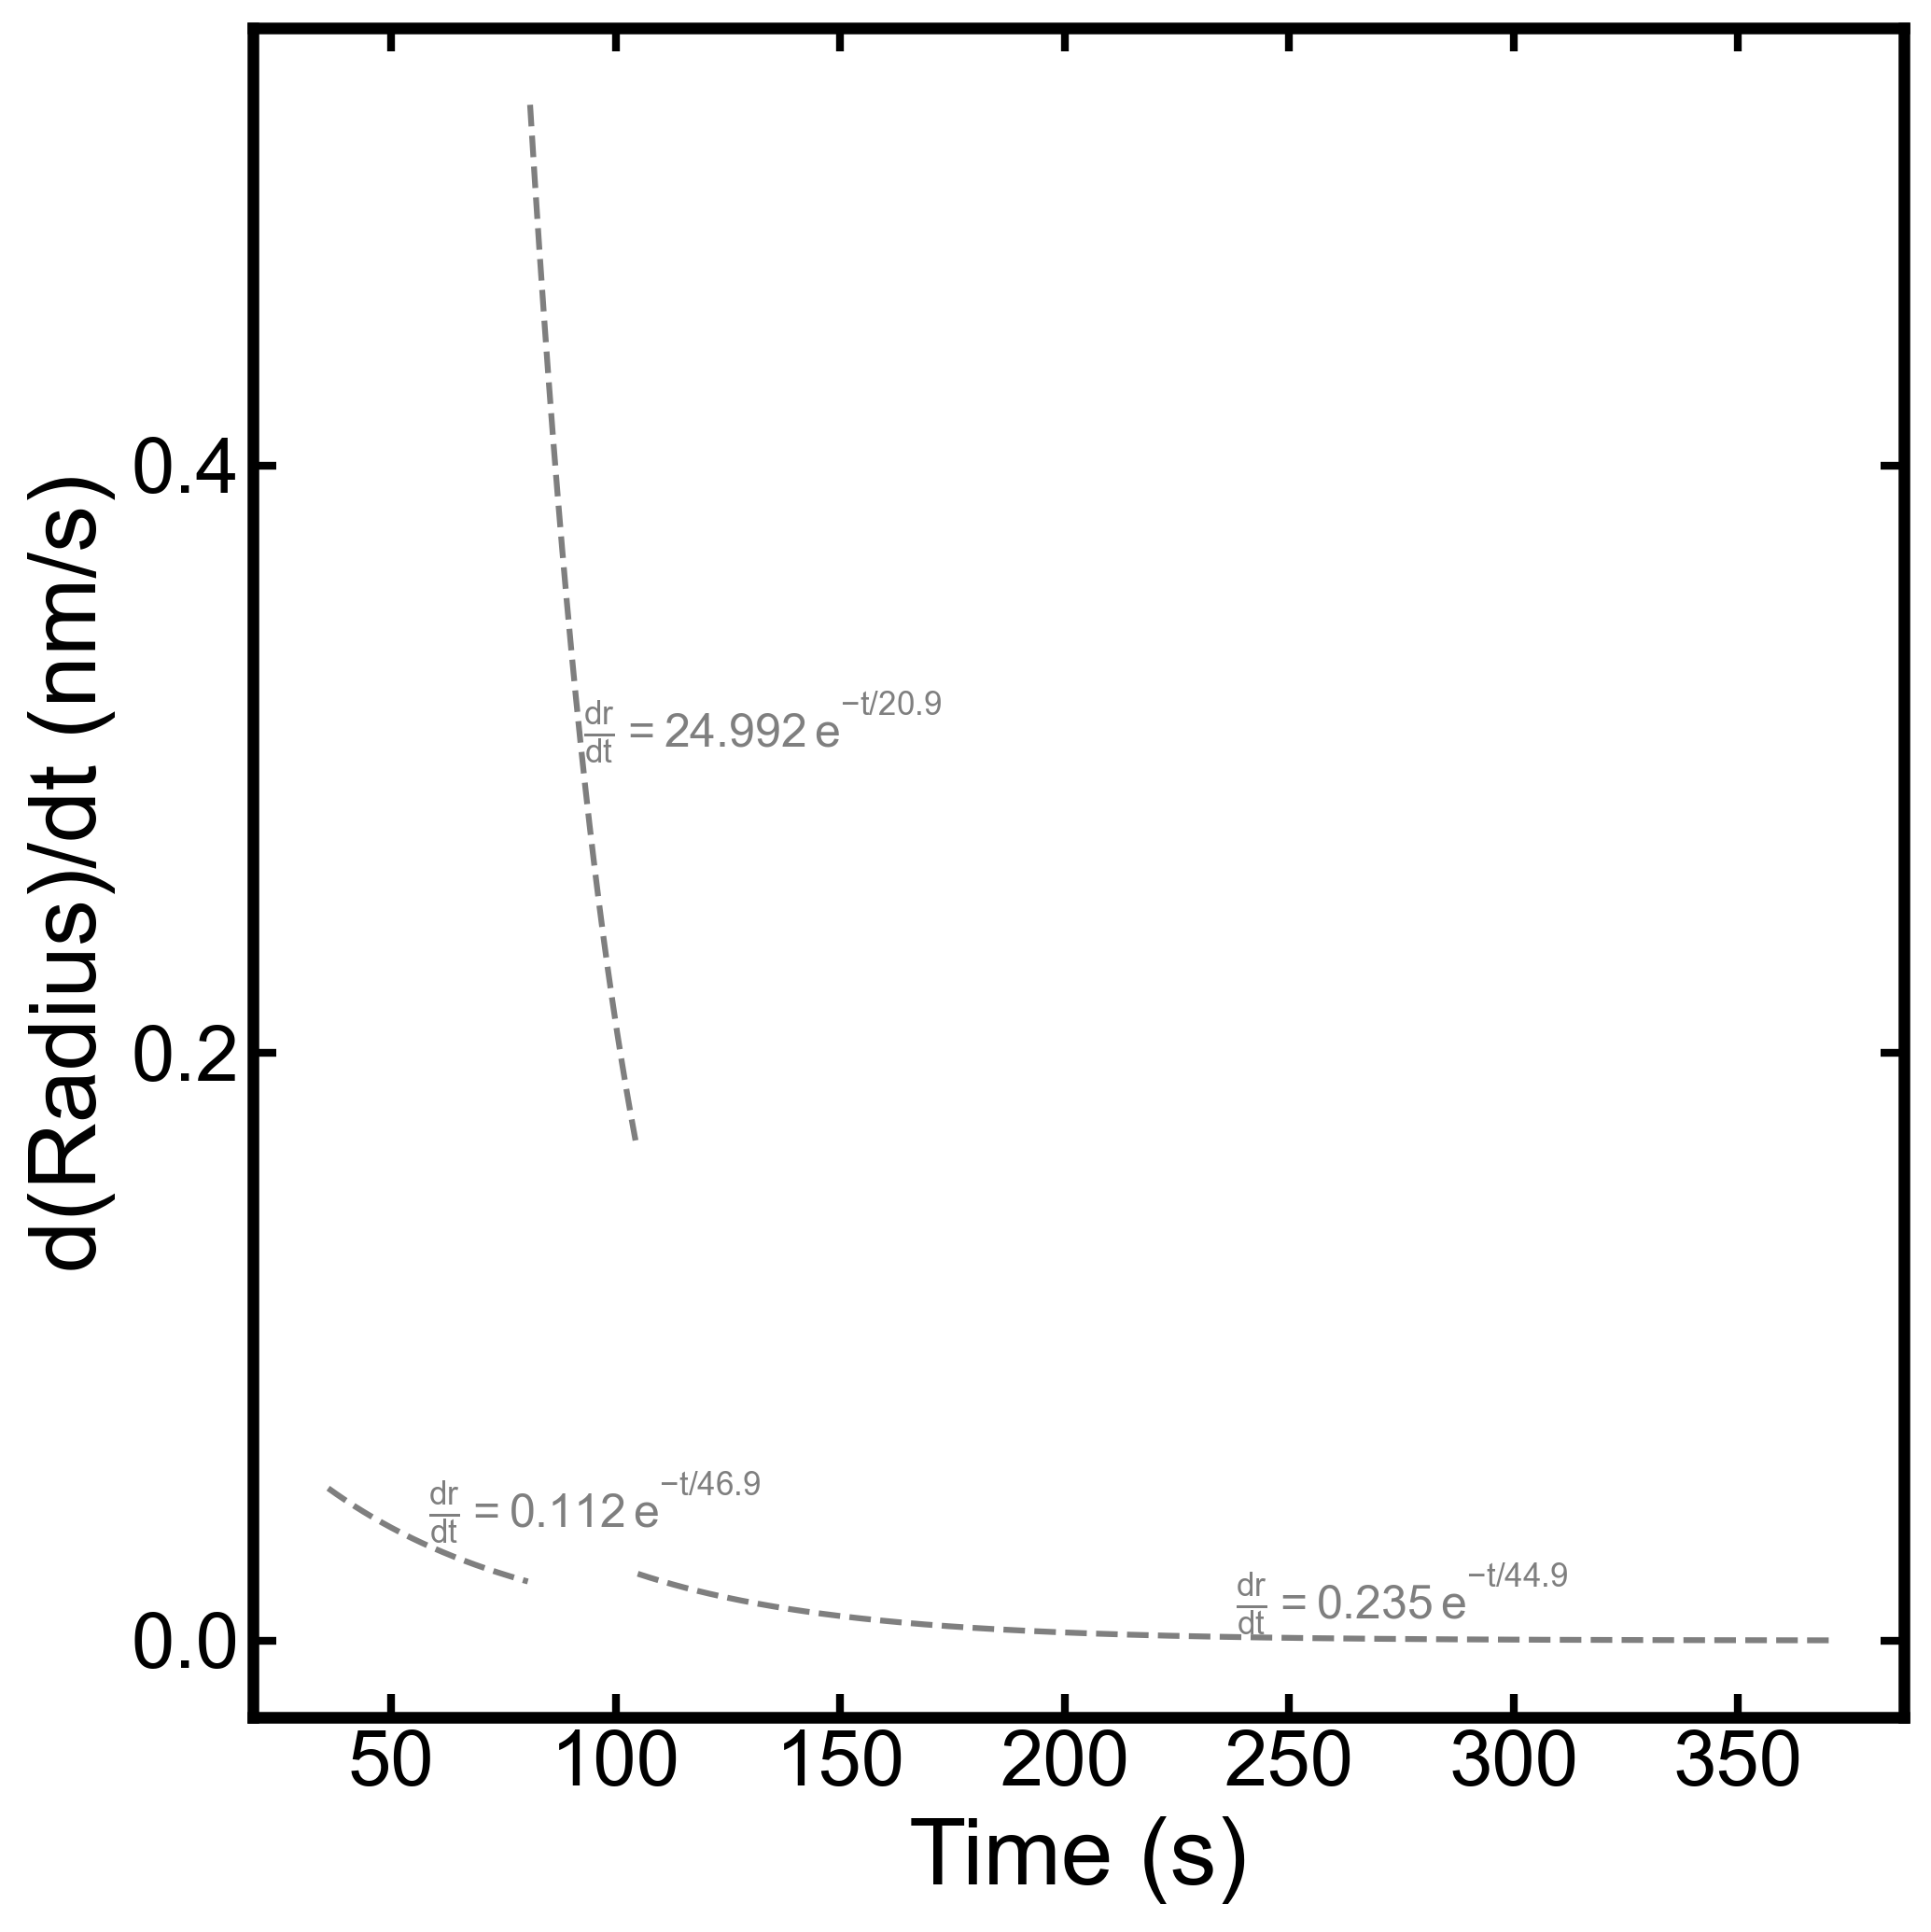

💾 Saved: E:\MAPI_sean\Brus_Working_data\260106_Data\Radius Growth Rate vs Time\260106_PL_FitResults_control_growth_rate.png


In [21]:
# ==== Growth-rate plotting (dr/dt) from in-memory FIT_MODELS ====
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from datetime import datetime

# ---------- Shared path helpers (self-contained) ----------
_DATA_DIR_SAVEFILE = Path.cwd() / ".selected_data_dir.txt"


def _get_data_dir_strict() -> Path:
    if "get_data_dir" in globals():
        try:
            p = Path(get_data_dir())
            if p.exists() and p.is_dir():
                return p
        except Exception:
            pass
    if _DATA_DIR_SAVEFILE.exists():
        p = Path(_DATA_DIR_SAVEFILE.read_text().strip())
        if p.exists() and p.is_dir():
            return p
        raise FileNotFoundError(
            f"Saved data_dir is invalid: {p}. Re-run the folder picker."
        )
    raise RuntimeError("No saved data_dir found. Re-run the folder picker cell.")


def _day_root() -> Path:
    day = datetime.now().strftime("%y%m%d")
    root = _get_data_dir_strict() / f"{day}_Data"
    root.mkdir(parents=True, exist_ok=True)
    return root


def _ensure_day_subdir(name: str) -> Path:
    out = _day_root() / name
    out.mkdir(parents=True, exist_ok=True)
    return out


def _date_prefix() -> str:
    return datetime.now().strftime("%y%m%d_")


# ---------- Parameters ----------
TIME_MODE = "norm"  # "norm" or "abs"
POINTS_PER_REGION = 300
FIGSIZE = (7, 7)

# Ensure FIT_MODELS exists (built by the interactive fitter cell)
if "FIT_MODELS" not in globals() or not FIT_MODELS:
    raise RuntimeError(
        "FIT_MODELS not found. Run the interactive fitter first to populate in-memory fits."
    )


def _region_bounds(r):
    if TIME_MODE == "abs":
        return float(r["t_start_abs"]), float(r["t_end_abs"])
    return float(r["t_start_norm"]), float(r["t_end_norm"])


def _region_derivative(r):
    return r["df_abs"] if TIME_MODE == "abs" else r["df_norm"]


def _coeff_and_eq_tex(A, tau):
    coeff = -A / tau
    return coeff, rf"$\frac{{dr}}{{dt}} = {coeff:.3f} \, e^{{-t/{tau:.1f}}}$"


def _style_axes(ax):
    ax.set_xlabel("Time (s)", fontsize=24, fontname="Arial", color="black")
    ax.set_ylabel("d(Radius)/dt (nm/s)", fontsize=24, fontname="Arial", color="black")
    ax.tick_params(
        axis="x",
        direction="in",
        top=True,
        width=2,
        length=6,
        labelsize=20,
        labelcolor="black",
    )
    ax.tick_params(
        axis="y",
        direction="in",
        right=True,
        width=2,
        length=6,
        labelsize=20,
        labelcolor="black",
    )
    for sp in ax.spines.values():
        sp.set_linewidth(3)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.locator_params(axis="y", nbins=5)


ALL_DATASETS = sorted(FIT_MODELS.keys())
palette = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()
    .get("color", ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"])
)
COLOR = {name: palette[i % len(palette)] for i, name in enumerate(ALL_DATASETS)}

# Output dir inside the parent/day folder
outdir = _ensure_day_subdir("Radius Growth Rate vs Time")
prefix = _date_prefix()

# --- Overlay ---
fig, ax = plt.subplots(figsize=FIGSIZE, dpi=300)
added = set()
for ds in ALL_DATASETS:
    info = FIT_MODELS[ds]
    col = COLOR[ds]
    first = True
    seg_idx = 0
    for r in info["regions"]:
        df = _region_derivative(r)
        if df is None:
            seg_idx += 1
            continue
        t0, t1 = _region_bounds(r)
        if not np.isfinite(t0) or not np.isfinite(t1) or t1 <= t0:
            seg_idx += 1
            continue
        t = np.linspace(t0, t1, POINTS_PER_REGION)
        y = df(t)
        label = ds if first and ds not in added else None
        ax.plot(t, y, "--", color=col, label=label)
        if label:
            added.add(ds)
            first = False
        seg_idx += 1

_style_axes(ax)
ax.legend(frameon=False)
fig.tight_layout()

png_all = outdir / f"{prefix}ALL_DATASETS_growth_rate.png"
plt.savefig(png_all, bbox_inches="tight", dpi=300)
plt.show()
print(f"💾 Saved: {png_all}")

# --- Per-dataset ---
for ds in ALL_DATASETS:
    info = FIT_MODELS[ds]
    col = COLOR[ds]
    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=300)
    seg_idx = 0
    for r in info["regions"]:
        df = _region_derivative(r)
        A, tau = r.get("A", np.nan), r.get("tau", np.nan)
        if df is None or not np.isfinite(A) or not np.isfinite(tau):
            seg_idx += 1
            continue
        t0, t1 = _region_bounds(r)
        if not np.isfinite(t0) or not np.isfinite(t1) or t1 <= t0:
            seg_idx += 1
            continue
        t = np.linspace(t0, t1, POINTS_PER_REGION)
        y = df(t)
        ax.plot(t, y, "--", color=col)
        mid = len(t) // 2
        _, eq_tex = _coeff_and_eq_tex(A, tau)
        ax.text(
            t[mid],
            y[mid],
            eq_tex,
            color=col,
            fontsize=12,
            fontname="Arial",
            ha="left",
            va="bottom",
        )
        seg_idx += 1
    _style_axes(ax)
    fig.tight_layout()

    out_png = outdir / f"{prefix}{ds}_growth_rate.png"
    plt.savefig(out_png, bbox_inches="tight")
    plt.show()
    print(f"💾 Saved: {out_png}")

# Master workbook export (wide sheets with spacers → saved in `YYMMDD_Data`)

This cell builds **one Excel workbook** that consolidates all key outputs for the current run and saves one xlsx as `<YYMMDD>_Data/<YYMMDD>_Master_Data.xlsx`

In [22]:
# ==== Master workbook export (WIDE sheets + blank spacers; stored in YYMMDD_Data) ====
from pathlib import Path
from datetime import datetime
import re
import numpy as np
import pandas as pd

# ---------- helpers: strict data-dir ----------
_DATA_DIR_SAVEFILE = Path.cwd() / ".selected_data_dir.txt"


def _get_data_dir_strict() -> Path:
    if "get_data_dir" in globals():
        try:
            p = Path(get_data_dir())
            if p.exists() and p.is_dir():
                return p
        except Exception:
            pass
    if _DATA_DIR_SAVEFILE.exists():
        p = Path(_DATA_DIR_SAVEFILE.read_text().strip())
        if p.exists() and p.is_dir():
            return p
        raise FileNotFoundError(
            f"Saved data_dir is invalid: {p}. Re-run the folder picker."
        )
    raise RuntimeError("No saved data_dir found. Re-run the folder picker cell.")


def _day_root() -> Path:
    day = datetime.now().strftime("%y%m%d")
    root = _get_data_dir_strict() / f"{day}_Data"
    root.mkdir(parents=True, exist_ok=True)
    return root


def _date_prefix() -> str:
    return datetime.now().strftime("%y%m%d_")


# ---------- selection filtering (respect .selected_files.txt if present) ----------
_SELECTED_FILES_SAVEFILE = Path.cwd() / ".selected_files.txt"


def _load_saved_selected_files() -> list[Path]:
    if not _SELECTED_FILES_SAVEFILE.exists():
        return []
    lines = [
        ln.strip()
        for ln in _SELECTED_FILES_SAVEFILE.read_text().splitlines()
        if ln.strip()
    ]
    paths = [Path(ln) for ln in lines]
    return [p.resolve() for p in paths if p.exists() and p.is_file()]


def _find_sample_source_path(sample_obj):
    for attr in (
        "source_path",
        "filepath",
        "file_path",
        "path",
        "file",
        "filename",
        "source",
    ):
        if hasattr(sample_obj, attr):
            p = getattr(sample_obj, attr)
            if p is not None:
                try:
                    return Path(p)
                except Exception:
                    pass
    return None


def _matches_saved_selection(sample_name, sample_obj, selected_files):
    if not selected_files:
        return True
    selected_names = {p.name.lower() for p in selected_files}
    selected_stems = {p.stem.lower() for p in selected_files}
    src = _find_sample_source_path(sample_obj)
    if src is not None:
        src = Path(src)
        if src.name.lower() in selected_names or src.stem.lower() in selected_stems:
            return True
    if isinstance(sample_name, str) and sample_name.lower() in selected_stems:
        return True
    if hasattr(sample_obj, "name") and isinstance(sample_obj.name, str):
        if sample_obj.name.lower() in selected_stems:
            return True
    return False


# ---------- name safety ----------
def _sanitize_for_sheet(name: str) -> str:
    bad = r"[:\\/*?\[\]]"
    safe = re.sub(bad, "_", str(name))
    return safe[:31] if len(safe) > 31 else safe


def _unique_sheet_name(base: str, used: set[str]) -> str:
    name = _sanitize_for_sheet(base)
    if name not in used:
        used.add(name)
        return name
    for i in range(2, 999):
        suffix = f"~{i}"
        cand = (
            (name[: (31 - len(suffix))] + suffix)
            if len(name) + len(suffix) > 31
            else (name + suffix)
        )
        if cand not in used:
            used.add(cand)
            return cand
    raise RuntimeError("Could not generate a unique sheet name.")


def _sanitize_for_column(name: str) -> str:
    return re.sub(r"[\r\n\t]", " ", str(name)).strip()


# ---------- optional: rebuild FIT_MODELS from saved fit_data.xlsx (today) ----------
def _fitting_root_today() -> Path:
    return _day_root() / "Peak Energy and Radius vs Time (fitting)"


def _rebuild_fit_models_from_today() -> dict:
    root = _fitting_root_today()
    fit_models = {}
    for xlsx in root.glob("*.xlsx"):
        m = re.match(r"(\d{6})_(.+)_fit_data\.xlsx$", xlsx.name)
        if not m:
            continue
        name = m.group(2)
        try:
            df_fit = pd.read_excel(xlsx, sheet_name="Fit_Parameters")
            df_raw = pd.read_excel(xlsx, sheet_name="Raw_Data")
        except Exception:
            continue
        try:
            t_abs = np.asarray(df_raw["Time_abs (s)"]).astype(float)
            t_rel = np.asarray(df_raw["Time_rel (s)"]).astype(float)
            t0_offset = float(t_abs[0] - t_rel[0])
        except Exception:
            t0_offset = 0.0
        regions = []
        for _, row in df_fit.iterrows():
            A = (
                float(row.get("A", np.nan))
                if pd.notna(row.get("A", np.nan))
                else np.nan
            )
            tau = (
                float(row.get("Tau", np.nan))
                if pd.notna(row.get("Tau", np.nan))
                else np.nan
            )
            C = (
                float(row.get("C", np.nan))
                if pd.notna(row.get("C", np.nan))
                else np.nan
            )
            r2 = (
                float(row.get("R_squared", np.nan))
                if pd.notna(row.get("R_squared", np.nan))
                else np.nan
            )
            t_start_abs = (
                float(row.get("Dashed_Start_s_abs", np.nan))
                if pd.notna(row.get("Dashed_Start_s_abs", np.nan))
                else np.nan
            )
            t_end_abs = (
                float(row.get("Dashed_End_s_abs", np.nan))
                if pd.notna(row.get("Dashed_End_s_abs", np.nan))
                else np.nan
            )
            t_start_norm = (
                (t_start_abs - t0_offset) if np.isfinite(t_start_abs) else np.nan
            )
            t_end_norm = (t_end_abs - t0_offset) if np.isfinite(t_end_abs) else np.nan
            if np.isfinite(A) and np.isfinite(tau):
                f_norm = (
                    lambda A=A, tau=tau, C=C: (lambda t: A * np.exp(-t / tau) + C)
                )()
                df_norm = (
                    lambda A=A, tau=tau: (lambda t: -(A / tau) * np.exp(-t / tau))
                )()
                f_abs = (
                    lambda A=A, tau=tau, C=C, t0=t0_offset: (
                        lambda t_abs: A * np.exp(-(t_abs - t0) / tau) + C
                    )
                )()
                df_abs = (
                    lambda A=A, tau=tau, t0=t0_offset: (
                        lambda t_abs: -(A / tau) * np.exp(-(t_abs - t0) / tau)
                    )
                )()
            else:
                f_norm = df_norm = f_abs = df_abs = None
            regions.append(
                {
                    "A": A,
                    "tau": tau,
                    "C": C,
                    "R2": r2,
                    "t_start_norm": t_start_norm,
                    "t_end_norm": t_end_norm,
                    "t_start_abs": t_start_abs,
                    "t_end_abs": t_end_abs,
                    "f_norm": f_norm,
                    "df_norm": df_norm,
                    "f_abs": f_abs,
                    "df_abs": df_abs,
                }
            )
        fit_models[name] = {"t0_offset": t0_offset, "regions": regions}
    return fit_models


# ---------- WIDE concat with blank spacer columns ----------
def _wide_concat_with_spacers(
    blocks_list: list[pd.DataFrame], spacer_col_name: str = ""
) -> pd.DataFrame:
    """
    Side-by-side concat with a blank column between each block.
    Row count = max block length; shorter blocks padded with NaN rows.
    """
    if not blocks_list:
        return pd.DataFrame()
    max_len = max(len(df) for df in blocks_list)
    pieces = []
    for i, df in enumerate(blocks_list):
        d0 = df.reset_index(drop=True)
        if len(d0) < max_len:
            pad = pd.DataFrame(
                index=range(len(d0), max_len), columns=d0.columns, dtype=float
            )
            d0 = pd.concat([d0, pad], ignore_index=True)
        pieces.append(d0)
        if i < len(blocks_list) - 1:
            pieces.append(pd.DataFrame({spacer_col_name: [np.nan] * max_len}))
    return pd.concat(pieces, axis=1)


# ---------- wide builders (produce list of per-sample blocks) ----------
def _build_peakfwhm_wide(items, skip_first=True) -> pd.DataFrame:
    """Columns per sample: <sample>__time_s | <sample>__peak_eV | <sample>__fwhm, with blank spacer columns."""
    blocks = []
    for name, s in items:
        df = s.df_clean.copy()
        tcol, pcol, fcol = s.time_column, s.peak_column, s.fwhm_column
        for col in (tcol, pcol, fcol):
            if not pd.api.types.is_numeric_dtype(df[col]):
                df[col] = pd.to_numeric(df[col], errors="coerce")
        df = df.dropna(subset=[tcol, pcol, fcol])
        if skip_first and len(df) > 1:
            df = df.iloc[1:]
        if df.empty:
            continue
        pref = _sanitize_for_column(name)
        blocks.append(
            pd.DataFrame(
                {
                    f"{pref}__time_s": df[tcol].to_numpy(),
                    f"{pref}__peak_eV": df[pcol].to_numpy(),
                    f"{pref}__fwhm": df[fcol].to_numpy(),
                }
            )
        )
    return _wide_concat_with_spacers(blocks)


def _build_radiusresults_wide(items) -> pd.DataFrame:
    """Columns per sample: <sample>__time_s | <sample>__peak_energy_eV | <sample>__radius_nm, with blank spacers."""
    if "radius_results" not in globals() or not isinstance(radius_results, dict):
        return pd.DataFrame()
    blocks = []
    for name, _ in items:
        d = radius_results.get(name)
        if not isinstance(d, pd.DataFrame) or d.empty:
            continue
        pref = _sanitize_for_column(name)
        blocks.append(
            pd.DataFrame(
                {
                    f"{pref}__time_s": d["time_s"].to_numpy().flatten(),
                    f"{pref}__peak_energy_eV": d["peak_energy_eV"].to_numpy().flatten(),
                    f"{pref}__radius_nm": d["radius_nm"].to_numpy().flatten(),
                }
            )
        )
    return _wide_concat_with_spacers(blocks)


def _build_fitraw_wide(items) -> pd.DataFrame:
    """
    Read today's *_fit_data.xlsx Raw_Data and place each sample in 4 columns,
    with blank spacer columns between samples:
      <sample>__Time_rel_s | <sample>__Time_abs_s | <sample>__Peak_Energy_eV | <sample>__Radius_nm
    """
    root = _fitting_root_today()
    want = [name for name, _ in items]  # preserve order of items
    blocks = []
    files = {}
    for xlsx in root.glob("*.xlsx"):
        m = re.match(r"(\d{6})_(.+)_fit_data\.xlsx$", xlsx.name)
        if m:
            files[m.group(2)] = xlsx
    for sample in want:
        xlsx = files.get(sample)
        if not xlsx:
            continue
        try:
            dfr = pd.read_excel(xlsx, sheet_name="Raw_Data")
        except Exception:
            continue
        col_map = {
            "Time_rel (s)": None,
            "Time_abs (s)": None,
            "Peak Energy (eV)": None,
            "Radius (nm)": None,
        }
        for c in dfr.columns:
            cn = str(c).strip()
            if cn.startswith("Time_rel"):
                col_map["Time_rel (s)"] = c
            elif cn.startswith("Time_abs"):
                col_map["Time_abs (s)"] = c
            elif cn.startswith("Peak") and "eV" in cn:
                col_map["Peak Energy (eV)"] = c
            elif cn.startswith("Radius"):
                col_map["Radius (nm)"] = c
        if any(v is None for v in col_map.values()):
            continue
        pref = _sanitize_for_column(sample)
        blocks.append(
            pd.DataFrame(
                {
                    f"{pref}__Time_rel_s": dfr[col_map["Time_rel (s)"]].to_numpy(),
                    f"{pref}__Time_abs_s": dfr[col_map["Time_abs (s)"]].to_numpy(),
                    f"{pref}__Peak_Energy_eV": dfr[
                        col_map["Peak Energy (eV)"]
                    ].to_numpy(),
                    f"{pref}__Radius_nm": dfr[col_map["Radius (nm)"]].to_numpy(),
                }
            )
        )
    return _wide_concat_with_spacers(blocks)


# NEW ---------- GrowthRate_All (WIDE with blank spacer columns) ----------
def _build_growthrate_wide(
    items, fit_models: dict, time_mode: str = "norm", points_per_region: int = 300
) -> pd.DataFrame:
    """
    For each sample, put each fitted region side-by-side as two columns:
      <sample>__Reg<k>__t | <sample>__Reg<k>__drdt
    Insert one blank column between samples.
    """
    if not fit_models:
        return pd.DataFrame()

    def _bounds(r):
        if time_mode == "abs":
            return float(r.get("t_start_abs", np.nan)), float(
                r.get("t_end_abs", np.nan)
            )
        return float(r.get("t_start_norm", np.nan)), float(r.get("t_end_norm", np.nan))

    blocks = []
    for name, _s in items:
        info = fit_models.get(name)
        if not info:
            continue

        # collect per-region series for this sample
        cols = {}
        max_len = 0
        reg_idx = 0

        for r in info.get("regions", []):
            df = r.get("df_abs") if time_mode == "abs" else r.get("df_norm")
            if df is None:
                continue
            t0, t1 = _bounds(r)
            if not np.isfinite(t0) or not np.isfinite(t1) or t1 <= t0:
                continue
            reg_idx += 1
            t = np.linspace(t0, t1, points_per_region)
            y = df(t)

            pref = _sanitize_for_column(name)
            cols[f"{pref}__Reg{reg_idx}__t"] = pd.Series(t)
            cols[f"{pref}__Reg{reg_idx}__drdt"] = pd.Series(y)
            max_len = max(max_len, len(t))

        if not cols:
            continue

        # build block with unified length & index
        block = pd.concat(cols, axis=1)
        block = block.reindex(range(max_len))
        blocks.append(block)

    return _wide_concat_with_spacers(blocks)


# ---------- main exporter ----------
def export_master_workbook_wide(
    skip_first: bool = True, time_mode: str = "norm", points_per_region: int = 300
) -> Path:
    """
    Creates ONE Excel workbook with many sheets.
    * PeakFWHM_All, RadiusResults_All, Fit_Raw_All, GrowthRate_All are WIDE with a blank column between samples.
    * Fit_Parameters_All has a blank row between samples.
    Other sheets preserved (Summary, Physics_Terms, RAW_<sample>, Sources).
    """
    if "batch" not in globals() or not getattr(batch, "samples", None):
        raise RuntimeError(
            "No samples loaded (missing `batch`). Run earlier loader cells."
        )

    # gather items with selection
    sel = _load_saved_selected_files()
    items = [
        (n, s) for n, s in batch.samples.items() if _matches_saved_selection(n, s, sel)
    ]
    if sel:
        print(
            f"ℹ️ Using {len(items)} of {len(batch.samples)} samples based on previously selected files."
        )
    else:
        print("ℹ️ No saved file selection found; using all samples.")

    day_root = _day_root()
    out_xlsx = day_root / f"{_date_prefix()}Master_Data.xlsx"
    used_names = set()

    # ensure FIT_MODELS
    if "FIT_MODELS" not in globals() or not FIT_MODELS:
        FIT_MODELS_local = _rebuild_fit_models_from_today()
    else:
        FIT_MODELS_local = FIT_MODELS

    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        # Summary
        summary_rows = [
            {"Key": "Date", "Value": datetime.now().isoformat(timespec="seconds")},
            {"Key": "Data Root", "Value": str(day_root)},
            {"Key": "Samples Included", "Value": len(items)},
            {"Key": "TIME_MODE (growth)", "Value": time_mode},
            {"Key": "POINTS_PER_REGION", "Value": points_per_region},
        ]
        if "epsilon_pvk" in globals():
            summary_rows.append(
                {"Key": "epsilon_particle", "Value": float(globals()["epsilon_pvk"])}
            )
        elif "epsilon_r" in globals():
            summary_rows.append(
                {"Key": "epsilon_particle", "Value": float(globals()["epsilon_r"])}
            )
        if "me_star" in globals():
            summary_rows.append(
                {"Key": "me_star (m_e)", "Value": float(globals()["me_star"])}
            )
        if "mh_star" in globals():
            summary_rows.append(
                {"Key": "mh_star (m_e)", "Value": float(globals()["mh_star"])}
            )
        pd.DataFrame(summary_rows).to_excel(
            writer, sheet_name=_unique_sheet_name("Summary", used_names), index=False
        )

        # RAW_<sample> (original unfiltered data)
        for name, s in items:
            raw_sheet = _unique_sheet_name(
                f"RAW_{_sanitize_for_sheet(name)}", used_names
            )
            s.df_raw.to_excel(writer, sheet_name=raw_sheet, index=False)

        # PeakFWHM_All (WIDE + blank spacer columns)
        pf_wide = _build_peakfwhm_wide(items, skip_first=skip_first)
        if not pf_wide.empty:
            pf_wide.to_excel(
                writer,
                sheet_name=_unique_sheet_name("PeakFWHM_All", used_names),
                index=False,
            )

        # RadiusResults_All (WIDE + blank spacer columns)
        rr_wide = _build_radiusresults_wide(items)
        if not rr_wide.empty:
            rr_wide.to_excel(
                writer,
                sheet_name=_unique_sheet_name("RadiusResults_All", used_names),
                index=False,
            )

        # Fit_Parameters_All (LONG with blank spacer rows between samples)
        fit_root = _fitting_root_today()
        params_by_sample = {}
        for xlsx in fit_root.glob("*.xlsx"):
            m = re.match(r"(\d{6})_(.+)_fit_data\.xlsx$", xlsx.name)
            if not m:
                continue
            sample = m.group(2)
            if not any(sample == n for n, _ in items):
                continue
            try:
                dfp = pd.read_excel(xlsx, sheet_name="Fit_Parameters")
            except Exception:
                continue
            dfp = dfp.copy()
            dfp.insert(0, "sample", sample)
            params_by_sample[sample] = dfp

        if params_by_sample:
            first_df = next(iter(params_by_sample.values()))
            cols = list(first_df.columns)
            blocks = []
            order = [n for n, _ in items if n in params_by_sample]
            for i, samp in enumerate(order):
                dfp = params_by_sample[samp].reindex(columns=cols)
                blocks.append(dfp)
                if i < len(order) - 1:
                    blocks.append(pd.DataFrame({c: [np.nan] for c in cols}))
            fit_params_all = pd.concat(blocks, ignore_index=True)
            fit_params_all.to_excel(
                writer,
                sheet_name=_unique_sheet_name("Fit_Parameters_All", used_names),
                index=False,
            )

        # Fit_Raw_All (WIDE + blank spacer columns)
        fitraw_wide = _build_fitraw_wide(items)
        if not fitraw_wide.empty:
            fitraw_wide.to_excel(
                writer,
                sheet_name=_unique_sheet_name("Fit_Raw_All", used_names),
                index=False,
            )

        # NEW: GrowthRate_All (WIDE + blank spacer columns)
        gr_wide = _build_growthrate_wide(
            items,
            fit_models=FIT_MODELS_local,
            time_mode=time_mode,
            points_per_region=points_per_region,
        )
        if not gr_wide.empty:
            gr_wide.to_excel(
                writer,
                sheet_name=_unique_sheet_name("GrowthRate_All", used_names),
                index=False,
            )

        # Physics_Terms (if present)
        if (
            "terms_df" in globals()
            and isinstance(terms_df, pd.DataFrame)
            and not terms_df.empty
        ):
            terms_df.to_excel(
                writer,
                sheet_name=_unique_sheet_name("Physics_Terms", used_names),
                index=True,
            )

        # Sources mapping
        sources_rows = []
        for name, s in items:
            src = _find_sample_source_path(s)
            sources_rows.append(
                {"sample": name, "source_path": str(src) if src else ""}
            )
        pd.DataFrame(sources_rows).to_excel(
            writer, sheet_name=_unique_sheet_name("Sources", used_names), index=False
        )

    print(f"✅ Master workbook saved (wide + spacers): {out_xlsx.resolve()}")
    return out_xlsx


# ---- Run it ----
export_master_workbook_wide(
    skip_first=globals().get("skip_first", True),
    time_mode=globals().get("TIME_MODE", "norm"),
    points_per_region=globals().get("POINTS_PER_REGION", 300),
)

ℹ️ Using 7 of 7 samples based on previously selected files.
✅ Master workbook saved (wide + spacers): E:\MAPI_sean\Brus_Working_data\260106_Data\260106_Master_Data.xlsx


WindowsPath('E:/MAPI_sean/Brus_Working_data/260106_Data/260106_Master_Data.xlsx')

# Word Report Assembly (python-docx)
Compiles a per-sample report pulling all generated assets from today’s run.
- Inserts material parameters, Peak/FWHM plot, Energy+Radius-with-fits plot, and Growth-rate plot.
- Lists region absolute bounds and prints fitted equations + derivatives.
- Saves one DOCX per sample under `<YYMMDD>_Data/Reports/`.


In [23]:
# ==== Word report export (YYMMDD_Data/Reports) ====
import numpy as np
from docx import Document
from docx.shared import Inches


def _latest_match(folder: Path, pattern: str) -> Optional[Path]:
    paths = list(folder.glob(pattern))
    if not paths:
        return None
    paths.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return paths[0]


reports_dir = session.subdir("Reports")
fitting_root = session.subdir("Peak Energy and Radius vs Time (fitting)")
growth_root = session.subdir("Radius Growth Rate vs Time")
peakfwhm_root = session.subdir("Peak Position and FWHM vs Time")

names = list(radius_results.keys())
saved = load_selected_files()
if saved:
    stems = {p.stem.lower() for p in saved}
    names = [n for n in names if n.lower() in stems]

for name in names:
    d = radius_results.get(name)
    if not isinstance(d, pd.DataFrame) or d.empty:
        print(f"[WARN] {name}: empty radius results; skipping.")
        continue

    # locate images
    img_energy_radius = _latest_match(fitting_root, f"*_{name}_fit_regions.png")
    img_growth = _latest_match(growth_root, f"*_{name}_growth_rate.png")
    img_peak_fwhm = _latest_match(peakfwhm_root, f"*_{name}_peak_fwhm.png")
    if img_peak_fwhm is None:
        img_peak_fwhm = _latest_match(peakfwhm_root, "peak_fwhm_plot*.png")

    doc = Document()
    doc.add_heading(f"Results for {name}", level=1)

    doc.add_heading("Material Parameters", level=2)
    try:
        doc.add_paragraph(f"Effective mass of electron (m_e*): {float(me_star):.3f} mₑ")
        doc.add_paragraph(f"Effective mass of hole (m_h*): {float(mh_star):.3f} mₑ")
    except Exception:
        doc.add_paragraph("Effective masses: (not set)")
    try:
        doc.add_paragraph(
            f"Relative dielectric constant (εᵣ): {float(epsilon_pvk):.3f}"
        )
    except Exception:
        doc.add_paragraph("Relative dielectric constant (εᵣ): (not set)")
    doc.add_paragraph("")

    doc.add_heading("Peak Energy and FWHM vs Time", level=2)
    if img_peak_fwhm and img_peak_fwhm.exists():
        doc.add_picture(str(img_peak_fwhm), width=Inches(5))
    else:
        doc.add_paragraph("(No Peak/FWHM plot available.)")

    doc.add_heading("Peak Energy and Radius vs Time (with exponential fits)", level=2)
    if img_energy_radius and img_energy_radius.exists():
        doc.add_picture(str(img_energy_radius), width=Inches(5))
    else:
        doc.add_paragraph("(No energy+radius fit plot found.)")

    # Region bounds (absolute) + equations text (if FIT_MODELS present)
    doc.add_heading("Region Bounds (absolute seconds)", level=2)
    regs = []
    if "FIT_MODELS" in globals() and name in FIT_MODELS:
        regs = FIT_MODELS[name].get("regions", [])
    for i in range(3):
        if i < len(regs):
            r = regs[i]
            t0a, t1a = r.get("t_start_abs", np.nan), r.get("t_end_abs", np.nan)
            if np.isfinite(t0a) and np.isfinite(t1a):
                doc.add_paragraph(f"Region {i+1}: {t0a:.3f} to {t1a:.3f} s")
            else:
                doc.add_paragraph(f"Region {i+1}: (not available)")
        else:
            doc.add_paragraph(f"Region {i+1}: (not available)")
    doc.add_paragraph("")

    doc.add_heading("Fitting Equations and R² Values", level=2)

    def _fmt(A, tau, C, R2):
        if not np.isfinite([A, tau, C, R2]).all():
            return "Insufficient data to fit this region."
        return f"r(t) = {A:.3g} * exp(-t / {tau:.3g}) + {C:.3g},   R² = {R2:.3f}"

    for i in range(3):
        if i < len(regs):
            r = regs[i]
            A = r.get("A", np.nan)
            tau = r.get("tau", np.nan)
            C = r.get("C", np.nan)
            R2 = r.get("R2", np.nan)
            doc.add_paragraph(f"Region {i+1}: " + _fmt(A, tau, C, R2))
        else:
            doc.add_paragraph(f"Region {i+1}: Insufficient data.")
    doc.add_paragraph("")

    doc.add_heading("Derivative Equations", level=2)

    def _fmt_d(A, tau):
        if not np.isfinite([A, tau]).all():
            return "dr/dt not available for this region."
        return f"dr/dt = {-A/tau:.3g} * exp(-t / {tau:.3g})"

    for i in range(3):
        if i < len(regs):
            r = regs[i]
            A = r.get("A", np.nan)
            tau = r.get("tau", np.nan)
            doc.add_paragraph(f"Region {i+1}: " + _fmt_d(A, tau))
        else:
            doc.add_paragraph(f"Region {i+1}: dr/dt not available.")
    doc.add_paragraph("")

    doc.add_heading("Growth Rates vs Time", level=2)
    if img_growth and img_growth.exists():
        doc.add_picture(str(img_growth), width=Inches(5))
    else:
        doc.add_paragraph("(No growth-rate plot found.)")

    doc_path = reports_dir / f"{session.prefix}{name}.docx"
    doc.save(str(doc_path))
    print(f"💾 Saved report: {doc_path}")

💾 Saved report: E:\MAPI_sean\Brus_Working_data\260106_Data\Reports\260106_PL_FitResults_1pct_ABA.docx
💾 Saved report: E:\MAPI_sean\Brus_Working_data\260106_Data\Reports\260106_PL_FitResults_1pct_AHA.docx
💾 Saved report: E:\MAPI_sean\Brus_Working_data\260106_Data\Reports\260106_PL_FitResults_1pct_APA.docx
💾 Saved report: E:\MAPI_sean\Brus_Working_data\260106_Data\Reports\260106_PL_FitResults_1pct_AVA.docx
💾 Saved report: E:\MAPI_sean\Brus_Working_data\260106_Data\Reports\260106_PL_FitResults_1pct_AVACl.docx
💾 Saved report: E:\MAPI_sean\Brus_Working_data\260106_Data\Reports\260106_PL_FitResults_1pct_AVAI.docx
💾 Saved report: E:\MAPI_sean\Brus_Working_data\260106_Data\Reports\260106_PL_FitResults_control.docx
